## Pair Trading Project: Coca-Cola vs Pepsi



## 1. Import Libraries and Setup

In [27]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


## 2. Download Historical Price Data and Save Adjusted Close Price Data to CSV Files

In [28]:
# Download and prepare data (fixed column names and alignment)
tickers = ['KO', 'PEP']
start_date = '1980-01-01'
end_date = '2025-10-01'

print(f"Downloading data for {tickers} from {start_date} to {end_date}...")
ko_data = yf.download('KO', start=start_date, end=end_date, auto_adjust=False, progress=False)
pep_data = yf.download('PEP', start=start_date, end=end_date, auto_adjust=False, progress=False)

# Extract adjusted close Series
ko_adj = ko_data['Adj Close']
pep_adj = pep_data['Adj Close']

# Set the name of the Series directly
ko_adj.name = 'KO'
pep_adj.name = 'PEP'

# Align on dates, drop missing, sort index
combined_data = pd.concat([ko_adj, pep_adj], axis=1).dropna().sort_index()

# Save
combined_data.to_csv('KO_PEP_combined_adj_close_price.csv')
print(f"\nData saved! Shape: {combined_data.shape}")
print(f"Date range: {combined_data.index[0].strftime('%Y-%m-%d')} to {combined_data.index[-1].strftime('%Y-%m-%d')}")


Data saved! Shape: (11531, 2)
Date range: 1980-01-02 to 2025-09-30


## 3. Visualize Adjusted Close Price Data

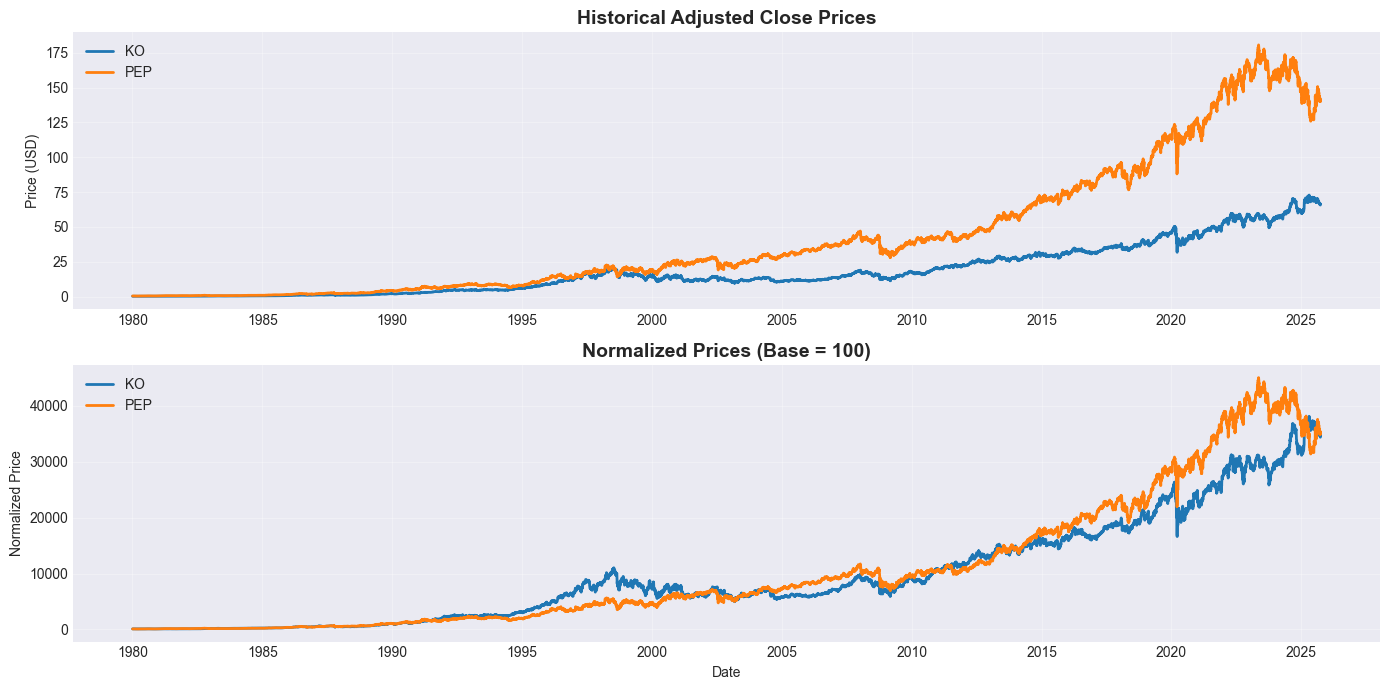

KO: $0.17 - $72.82
PEP: $0.33 - $180.58


In [29]:
# Visualize price data
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Absolute prices
axes[0].plot(combined_data.index, combined_data['KO'], label='KO', linewidth=2)
axes[0].plot(combined_data.index, combined_data['PEP'], label='PEP', linewidth=2)
axes[0].set_title('Historical Adjusted Close Prices', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Normalized prices
normalized_data = combined_data / combined_data.iloc[0] * 100
axes[1].plot(normalized_data.index, normalized_data['KO'], label='KO', linewidth=2)
axes[1].plot(normalized_data.index, normalized_data['PEP'], label='PEP', linewidth=2)
axes[1].set_title('Normalized Prices (Base = 100)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Normalized Price')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"KO: ${combined_data['KO'].min():.2f} - ${combined_data['KO'].max():.2f}")
print(f"PEP: ${combined_data['PEP'].min():.2f} - ${combined_data['PEP'].max():.2f}")

## 4. Pairs Trading Simulation Setup

### Trading Strategy:
- **Entry Date**: October 9, 2023 (close of market)
- **Analysis Date**: October 16, 2023 (Day 7 - 5 trading days later)
- **Initial Capital**: USD $100,000
- **Strategy**: Short $100,000 of KO, Long $100,000 of PEP
- **Cash Rate**: 5% per year
- **Simulation Period**: 60 trading days (for price path simulation)
- **Number of Paths**: 1,000,000
- **Focus**: P&L analysis on October 16, 2023

In [30]:
# Calculate historical parameters
trade_date = '2023-10-09'
lookback_period = 5000  # ~20 years

historical_data = combined_data[combined_data.index < trade_date].tail(lookback_period)

# Calculate returns and statistics
ko_returns = historical_data['KO'].pct_change().dropna()
pep_returns = historical_data['PEP'].pct_change().dropna()

ko_mean, ko_std = ko_returns.mean(), ko_returns.std()
pep_mean, pep_std = pep_returns.mean(), pep_returns.std()
correlation = ko_returns.corr(pep_returns)

# Linear regression for hedge ratio: KO = alpha + beta * PEP
X = historical_data['PEP'].values
y = historical_data['KO'].values
beta, alpha = np.polyfit(X, y, 1)

# Calculate R²
y_pred = beta * X + alpha
r_squared = 1 - (np.sum((y - y_pred) ** 2) / np.sum((y - y.mean()) ** 2))

# Spread statistics - use 60-day rolling window for current regime
linear_spread = historical_data['KO'] - beta * historical_data['PEP']
rolling_window_for_sim = 60
spread_mean = linear_spread.tail(rolling_window_for_sim).mean()  # Recent mean
spread_std = linear_spread.tail(rolling_window_for_sim).std()    # Recent std
spread_mean_all = linear_spread.mean()  # Historical mean for reference
spread_std_all = linear_spread.std()    # Historical std for reference

# Mean reversion parameters for O-U process
# Use a conservative estimate: kappa reflects typical mean reversion in equity spreads
# Use half-life 10 days
half_life_days = 10
kappa = np.log(2) / half_life_days  # Mean reversion speed

# Trade date prices
ko_price_trade = combined_data.loc[trade_date, 'KO']
pep_price_trade = combined_data.loc[trade_date, 'PEP']

print("Historical Parameters (20 years):")
print("=" * 60)
print(f"KO:  μ={ko_mean:.6f} ({ko_mean*252:.2%}/yr), σ={ko_std:.6f} ({ko_std*np.sqrt(252):.2%}/yr)")
print(f"PEP: μ={pep_mean:.6f} ({pep_mean*252:.2%}/yr), σ={pep_std:.6f} ({pep_std*np.sqrt(252):.2%}/yr)")
print(f"Correlation: {correlation:.4f}")
print(f"\nHedge Ratio: β={beta:.4f}, α={alpha:.4f}, R²={r_squared:.4f}")
print(f"Spread (St=KO-β*PEP):")
print(f"  Historical (all data): μ=${spread_mean_all:.4f}, σ=${spread_std_all:.4f}")
print(f"  Recent (60-day):       μ=${spread_mean:.4f}, σ=${spread_std:.4f} [USED FOR SIMULATION]")
print(f"Mean Reversion: κ={kappa:.4f} (half-life ~{half_life_days} days)")
print(f"\nPrices on {trade_date}: KO=${ko_price_trade:.2f}, PEP=${pep_price_trade:.2f}")
print(f"Current Spread: ${ko_price_trade - beta * pep_price_trade:.4f}")

Historical Parameters (20 years):
KO:  μ=0.000351 (8.84%/yr), σ=0.011552 (18.34%/yr)
PEP: μ=0.000413 (10.40%/yr), σ=0.011264 (17.88%/yr)
Correlation: 0.6890

Hedge Ratio: β=0.3330, α=4.6307, R²=0.9604
Spread (St=KO-β*PEP):
  Historical (all data): μ=$4.6307, σ=$2.7545
  Recent (60-day):       μ=$0.0041, σ=$0.7800 [USED FOR SIMULATION]
Mean Reversion: κ=0.0693 (half-life ~10 days)

Prices on 2023-10-09: KO=$49.80, PEP=$150.67
Current Spread: $-0.3792


## 5. Portfolio Construction & Risk Metrics

### Trading Setup:
- LONG PEP: $100,000 worth (664 shares @ $150.67)
- SHORT KO: $100,000 worth (2,008 shares @ $49.80)
- Net cash position: $0 (fully deployed)
- Initial capital: $100k
- **Gross exposure: $200,000** (This is NOT a hedged position!)

### Goal:
Calculate expected P&L and risk metrics over 60 days

In [31]:
# Simulation parameters
n_paths = 1_000_000
n_days = 60
initial_capital = 100_000
risk_free_rate_annual = 0.05
risk_free_rate_daily = (1 + risk_free_rate_annual) ** (1/252) - 1

# Initial positions - FULL $100k LONG PEP, FULL $100k SHORT KO (NOT HEDGED!)
# IMPORTANT: We use $100k to buy PEP AND $100k to short KO = $200k gross exposure
pep_shares = int(initial_capital / pep_price_trade)  # LONG: 664 shares
ko_shares = int(initial_capital / ko_price_trade)    # SHORT: 2008 shares (positive = number shorted)

# Cash flows:
# - Start with $100k
# - Spend $100k buying PEP → -$100k
# - Receive $100k from shorting KO → +$100k
# - Result: $100k cash remaining
pep_cost = pep_shares * pep_price_trade              # Money spent on PEP
ko_proceeds = ko_shares * ko_price_trade             # Money received from shorting KO
cash_position = initial_capital - pep_cost + ko_proceeds  # Net cash = $100k

# Portfolio value = cash + long positions - short positions
initial_portfolio_value = cash_position + (pep_shares * pep_price_trade) - (ko_shares * ko_price_trade)

print("Initial Trading Position:")
print("=" * 60)
print(f"Starting Capital:     ${initial_capital:,.2f}")
print(f"\nLong PEP:  {pep_shares:,} shares × ${pep_price_trade:.2f} = ${pep_cost:,.2f} (spent)")
print(f"Short KO:  {ko_shares:,} shares × ${ko_price_trade:.2f} = ${ko_proceeds:,.2f} (received)")
print(f"\nGross Exposure:       ${pep_cost + ko_proceeds:,.2f} (200% of capital)")
print(f"Net Cash Remaining:   ${cash_position:,.2f}")
print(f"\nPosition Values:")
print(f"  LONG  PEP: ${pep_shares * pep_price_trade:,.2f}")
print(f"  SHORT KO:  ${ko_shares * ko_price_trade:,.2f}")
print(f"\nInitial Portfolio Value: ${initial_portfolio_value:,.2f}")
print(f"Initial Spread: S₀ = KO - β*PEP = ${ko_price_trade - beta * pep_price_trade:.2f}")

Initial Trading Position:
Starting Capital:     $100,000.00

Long PEP:  663 shares × $150.67 = $99,892.05 (spent)
Short KO:  2,008 shares × $49.80 = $99,990.14 (received)

Gross Exposure:       $199,882.20 (200% of capital)
Net Cash Remaining:   $100,098.09

Position Values:
  LONG  PEP: $99,892.05
  SHORT KO:  $99,990.14

Initial Portfolio Value: $100,000.00
Initial Spread: S₀ = KO - β*PEP = $-0.38


## 6. Generate Correlated Price Paths with Mean Reversion

**Variance-Based O-U Distribution**: The O-U mean-reversion adjustment is distributed to KO and PEP using weights based on their variance contributions to the spread:
- **ΔKO_ou** = ou_adjustment × (1 / (1 + β²))
- **ΔPEP_ou** = -ou_adjustment × (β / (1 + β²))

This ensures the spread change exactly equals the O-U adjustment: ΔS = ΔKO_ou - β·ΔPEP_ou = ou_adjustment.

In [32]:
np.random.seed(111111)

# Correlation structure
corr_matrix = np.array([[1.0, correlation], [correlation, 1.0]])
cholesky = np.linalg.cholesky(corr_matrix)

# Initialize price arrays
ko_prices = np.zeros((n_paths, n_days + 1))
pep_prices = np.zeros((n_paths, n_days + 1))
ko_prices[:, 0] = ko_price_trade
pep_prices[:, 0] = pep_price_trade

# O-U spread volatility
spread_volatility = spread_std * np.sqrt(2 * kappa)

print(f"Generating {n_paths:,} correlated price paths with O-U mean reversion...")

# Monte Carlo simulation: GBM + Ornstein-Uhlenbeck mean reversion
dt = 1

# Correct O-U adjustment weights based on variance contributions
# These ensure that ΔKO_ou - β * ΔPEP_ou = ou_adjustment (100% of mean-reversion force)
weight_ko = 1 / (1 + beta**2)
weight_pep = beta / (1 + beta**2)

print(f"O-U adjustment weights: KO={weight_ko:.6f}, PEP={weight_pep:.6f}")
print(f"Verification: {weight_ko:.6f} - β*(-{weight_pep:.6f}) = {weight_ko + beta * weight_pep:.6f} ✓")

for day in range(n_days):
    # Generate random shocks (3 sources: 2 for stocks, 1 for spread)
    z = np.random.standard_normal((n_paths, 3))
    corr_z = z[:, :2] @ cholesky.T  # Correlated stock shocks
    
    # GBM returns
    ko_return = (ko_mean - 0.5 * ko_std**2) * dt + ko_std * np.sqrt(dt) * corr_z[:, 0]
    pep_return = (pep_mean - 0.5 * pep_std**2) * dt + pep_std * np.sqrt(dt) * corr_z[:, 1]
    
    # O-U mean reversion adjustment
    current_spread = ko_prices[:, day] - beta * pep_prices[:, day]
    ou_drift = kappa * (spread_mean - current_spread) * dt
    ou_diffusion = spread_volatility * np.sqrt(dt) * z[:, 2]
    ou_adjustment = ou_drift + ou_diffusion
    
    # Distribute O-U adjustment to stocks using variance-based weights
    # This ensures the full mean-reversion force is applied to the spread
    ko_ou_return = (ou_adjustment * weight_ko) / ko_prices[:, day]
    pep_ou_return = -(ou_adjustment * weight_pep) / pep_prices[:, day]
    
    # Update prices
    ko_prices[:, day + 1] = ko_prices[:, day] * np.exp(ko_return + ko_ou_return)
    pep_prices[:, day + 1] = pep_prices[:, day] * np.exp(pep_return + pep_ou_return)

final_spreads = ko_prices[:, -1] - beta * pep_prices[:, -1]
print(f"Complete! KO: ${ko_prices.min():.2f}-${ko_prices.max():.2f}, PEP: ${pep_prices.min():.2f}-${pep_prices.max():.2f}")
print(f"Final spread: μ=${final_spreads.mean():.2f}, σ=${final_spreads.std():.2f}")


Generating 1,000,000 correlated price paths with O-U mean reversion...
O-U adjustment weights: KO=0.900169, PEP=0.299774
Verification: 0.900169 - β*(-0.299774) = 1.000000 ✓
Complete! KO: $33.40-$77.86, PEP: $99.46-$243.57
Final spread: μ=$-0.04, σ=$1.50
Complete! KO: $33.40-$77.86, PEP: $99.46-$243.57
Final spread: μ=$-0.04, σ=$1.50


### Verification: Mean Reversion Correction

Verify that the corrected weights properly apply the intended O-U adjustment to the spread.

In [33]:
# Verify the O-U adjustment: Mathematical proof that weights are correct
print("=" * 70)
print("MATHEMATICAL VERIFICATION: O-U Adjustment Weights")
print("=" * 70)

print(f"\nGiven: β = {beta:.4f}")
print(f"\nWeights used:")
print(f"  weight_ko  = 1 / (1 + β²) = {weight_ko:.6f}")
print(f"  weight_pep = β / (1 + β²) = {weight_pep:.6f}")

print(f"\nProof that spread change = ou_adjustment:")
print(f"  ΔS = ΔKO_ou - β * ΔPEP_ou")
print(f"     = (ou_adjustment * {weight_ko:.6f}) - β * (ou_adjustment * (-{weight_pep:.6f}))")
print(f"     = ou_adjustment * ({weight_ko:.6f} + β * {weight_pep:.6f})")
print(f"     = ou_adjustment * {weight_ko + beta * weight_pep:.6f}")
print(f"     = ou_adjustment * (1 + β²)/(1 + β²)")
print(f"     = ou_adjustment  ✓")

print(f"\nThis ensures 100% of the mean-reversion force is applied to the spread.")
print(f"\nNote: Previous approach using 1/(1+β) would only apply:")
print(f"  (1 + β²)/(1 + β) = {(1 + beta**2)/(1 + beta):.6f} ≈ {(1 + beta**2)/(1 + beta)*100:.1f}% of the adjustment")
print("=" * 70)

MATHEMATICAL VERIFICATION: O-U Adjustment Weights

Given: β = 0.3330

Weights used:
  weight_ko  = 1 / (1 + β²) = 0.900169
  weight_pep = β / (1 + β²) = 0.299774

Proof that spread change = ou_adjustment:
  ΔS = ΔKO_ou - β * ΔPEP_ou
     = (ou_adjustment * 0.900169) - β * (ou_adjustment * (-0.299774))
     = ou_adjustment * (0.900169 + β * 0.299774)
     = ou_adjustment * 1.000000
     = ou_adjustment * (1 + β²)/(1 + β²)
     = ou_adjustment  ✓

This ensures 100% of the mean-reversion force is applied to the spread.

Note: Previous approach using 1/(1+β) would only apply:
  (1 + β²)/(1 + β) = 0.833373 ≈ 83.3% of the adjustment


## 7. Calculate Portfolio Values

In [34]:
# Calculate portfolio values over 60 days
cash_values = np.zeros((n_paths, n_days + 1))
cash_values[:, 0] = cash_position

# Cash grows at risk-free rate
for day in range(1, n_days + 1):
    cash_values[:, day] = cash_values[:, day - 1] * (1 + risk_free_rate_daily)

# Portfolio value = cash + long positions - short positions
# We are LONG PEP and SHORT KO
pep_position_values = pep_shares * pep_prices      # Long position (positive)
ko_position_values = ko_shares * ko_prices         # Short position (subtract this)
portfolio_values = cash_values + pep_position_values - ko_position_values
pnl = portfolio_values - initial_portfolio_value   # P&L relative to initial $100k

# Focus on Day 7 (October 16, 2023) - 5 trading days after entry
day_7_index = 5
day_7_pnl = pnl[:, day_7_index]
day_7_portfolio_values = portfolio_values[:, day_7_index]

print("=" * 70)
print("DAY 7 (OCTOBER 16, 2023) - SIMULATION RESULTS")
print("=" * 70)
print(f"\nPortfolio Statistics:")
print(f"  Mean Value:   ${day_7_portfolio_values.mean():,.2f}")
print(f"  Median Value: ${np.median(day_7_portfolio_values):,.2f}")
print(f"  Range:        [${day_7_portfolio_values.min():,.2f}, ${day_7_portfolio_values.max():,.2f}]")
print(f"\nP&L Statistics:")
print(f"  Mean P&L:     ${day_7_pnl.mean():,.2f}")
print(f"  Median P&L:   ${np.median(day_7_pnl):,.2f}")
print(f"  Std Dev:      ${day_7_pnl.std():,.2f}")
print("=" * 70)

DAY 7 (OCTOBER 16, 2023) - SIMULATION RESULTS

Portfolio Statistics:
  Mean Value:   $99,883.78
  Median Value: $99,887.04
  Range:        [$89,909.98, $109,417.49]

P&L Statistics:
  Mean P&L:     $-116.22
  Median P&L:   $-112.96
  Std Dev:      $2,104.35


## 8. Risk Metrics for October 16, 2023

In [35]:
# Day 7 Risk metrics and statistics
day_7_returns = day_7_pnl / initial_portfolio_value  # Returns relative to initial portfolio value

expected_pnl_day7 = day_7_pnl.mean()
pnl_std_day7 = day_7_pnl.std()
expected_return_day7 = day_7_returns.mean()
return_std_day7 = day_7_returns.std()

# Percentiles
percentile_5_day7 = np.percentile(day_7_pnl, 5)
percentile_95_day7 = np.percentile(day_7_pnl, 95)
var_95_day7 = -percentile_5_day7  # VaR is positive number representing potential loss
cvar_95_day7 = -day_7_pnl[day_7_pnl <= percentile_5_day7].mean()  # CVaR (expected loss beyond VaR)

prob_profit_day7 = (day_7_pnl > 0).mean()

print("=" * 70)
print("OCTOBER 16, 2023 (DAY 7) - RISK ANALYSIS")
print("=" * 70)
print(f"\nExpected P&L:      ${expected_pnl_day7:,.2f} ({expected_return_day7:.2%})")
print(f"P&L Std Dev:       ${pnl_std_day7:,.2f} ({return_std_day7:.2%})")
print(f"Probability Profit: {prob_profit_day7:.2%}")

print(f"\nRisk Metrics (Loss Convention - Positive = Loss):")
print(f"  VaR 95% (5th %ile):  ${var_95_day7:,.2f}")
print(f"  CVaR 95%:            ${cvar_95_day7:,.2f}")

print(f"\nP&L Distribution Percentiles:")
print(f"  1st:   ${np.percentile(day_7_pnl, 1):>10,.2f} ({np.percentile(day_7_pnl, 1)/initial_portfolio_value:>6.2%})")
print(f"  5th:   ${percentile_5_day7:>10,.2f} ({percentile_5_day7/initial_portfolio_value:>6.2%})")
print(f"  25th:  ${np.percentile(day_7_pnl, 25):>10,.2f} ({np.percentile(day_7_pnl, 25)/initial_portfolio_value:>6.2%})")
print(f"  50th:  ${np.percentile(day_7_pnl, 50):>10,.2f} ({np.percentile(day_7_pnl, 50)/initial_portfolio_value:>6.2%})")
print(f"  75th:  ${np.percentile(day_7_pnl, 75):>10,.2f} ({np.percentile(day_7_pnl, 75)/initial_portfolio_value:>6.2%})")
print(f"  95th:  ${percentile_95_day7:>10,.2f} ({percentile_95_day7/initial_portfolio_value:>6.2%})")
print(f"  99th:  ${np.percentile(day_7_pnl, 99):>10,.2f} ({np.percentile(day_7_pnl, 99)/initial_portfolio_value:>6.2%})")

print(f"\n90% Confidence Interval: [${percentile_5_day7:,.2f}, ${percentile_95_day7:,.2f}]")


OCTOBER 16, 2023 (DAY 7) - RISK ANALYSIS

Expected P&L:      $-116.22 (-0.12%)
P&L Std Dev:       $2,104.35 (2.10%)
Probability Profit: 47.86%

Risk Metrics (Loss Convention - Positive = Loss):
  VaR 95% (5th %ile):  $3,583.64
  CVaR 95%:            $4,464.62

P&L Distribution Percentiles:
  1st:   $ -5,017.38 (-5.02%)
  5th:   $ -3,583.64 (-3.58%)
  25th:  $ -1,535.56 (-1.54%)
  50th:  $   -112.96 (-0.11%)
  75th:  $  1,304.34 ( 1.30%)
  95th:  $  3,337.12 ( 3.34%)
  99th:  $  4,763.51 ( 4.76%)

90% Confidence Interval: [$-3,583.64, $3,337.12]
  50th:  $   -112.96 (-0.11%)
  75th:  $  1,304.34 ( 1.30%)
  95th:  $  3,337.12 ( 3.34%)
  99th:  $  4,763.51 ( 4.76%)

90% Confidence Interval: [$-3,583.64, $3,337.12]


## 9. Visualizations 


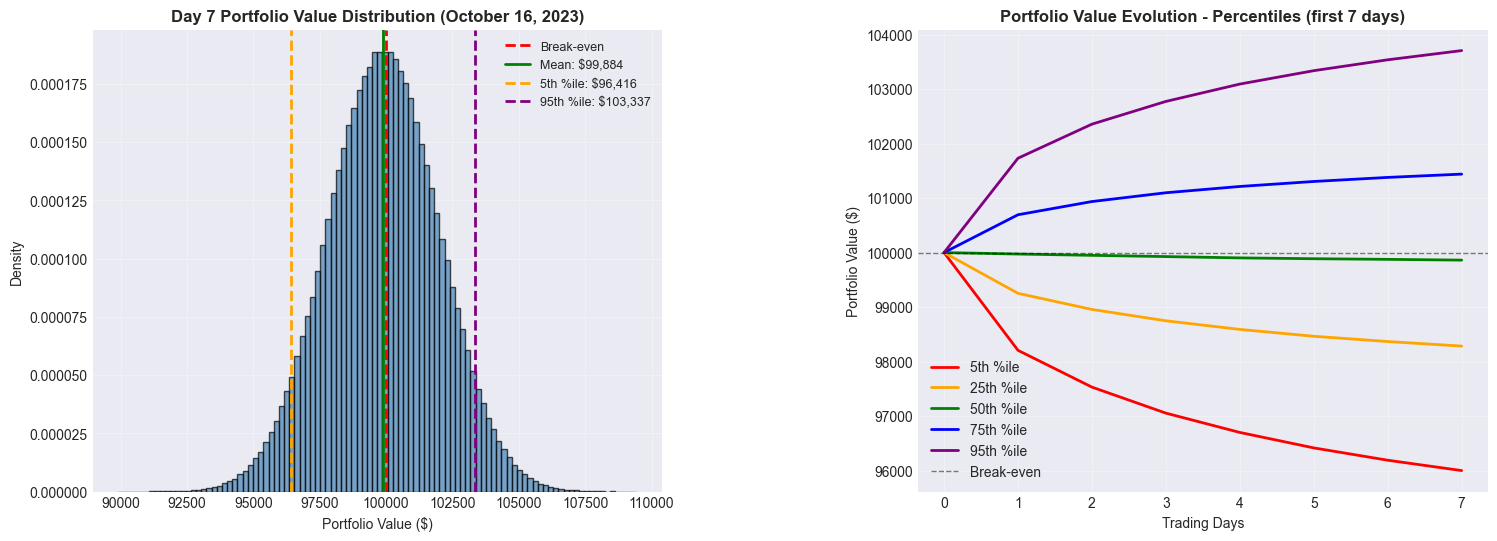

In [36]:
# Improve spacing between the two plots
fig = plt.figure(figsize=(18, 6))

# 1. Day 7 P&L distribution (MAIN FOCUS)
ax4 = fig.add_subplot(1, 2, 1)
ax4.hist(day_7_portfolio_values, bins=100, alpha=0.7, color='steelblue', edgecolor='black', density=True)
ax4.axvline(x=initial_portfolio_value, color='red', linestyle='--', linewidth=2, label='Break-even')
ax4.axvline(x=day_7_portfolio_values.mean(), color='green', linestyle='-', linewidth=2, 
            label=f'Mean: ${day_7_portfolio_values.mean():,.0f}')
ax4.axvline(x=np.percentile(day_7_portfolio_values, 5), color='orange', linestyle='--', linewidth=2, 
            label=f'5th %ile: ${np.percentile(day_7_portfolio_values, 5):,.0f}')
ax4.axvline(x=np.percentile(day_7_portfolio_values, 95), color='purple', linestyle='--', linewidth=2, 
            label=f'95th %ile: ${np.percentile(day_7_portfolio_values, 95):,.0f}')
ax4.set_title('Day 7 Portfolio Value Distribution (October 16, 2023)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Portfolio Value ($)')
ax4.set_ylabel('Density')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

# 2. P&L evolution (show first 7 days)
ax5 = fig.add_subplot(1, 2, 2)
days_to_show_7 = 7
days_axis_7 = np.arange(days_to_show_7 + 1)
percentiles_to_plot = [5, 25, 50, 75, 95]
colors = ['red', 'orange', 'green', 'blue', 'purple']
for p, color in zip(percentiles_to_plot, colors):
    portfolio_percentile = np.percentile(portfolio_values[:, :days_to_show_7+1], p, axis=0)
    ax5.plot(days_axis_7, portfolio_percentile, label=f'{p}th %ile', color=color, linewidth=2)

ax5.axhline(y=initial_portfolio_value, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Break-even')
ax5.set_title('Portfolio Value Evolution - Percentiles (first 7 days)', fontsize=12, fontweight='bold')
ax5.set_xlabel('Trading Days')
ax5.set_ylabel('Portfolio Value ($)')
ax5.legend()
ax5.grid(True, alpha=0.3)

# Increase horizontal spacing between subplots
fig.subplots_adjust(wspace=0.45)
plt.show()

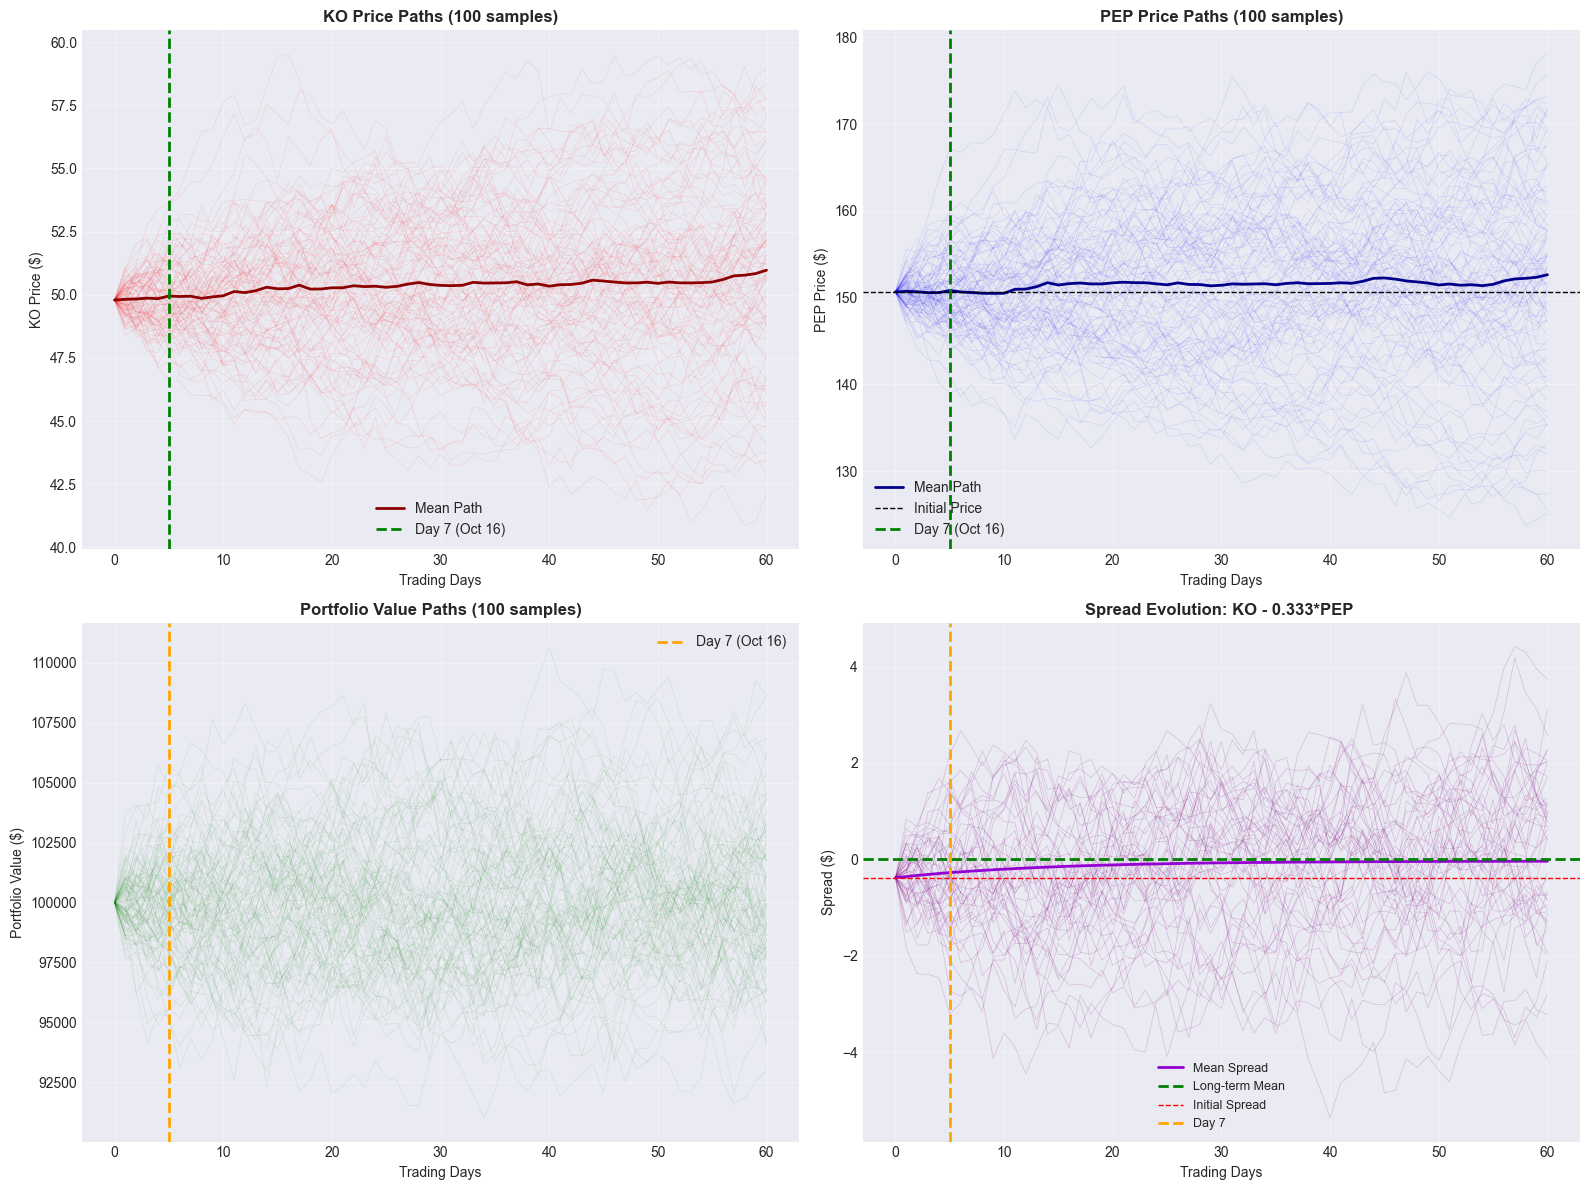

In [37]:
# Visualizations focused on Day 7 (using 60 days) (using 60 days) (using 60 days)
fig = plt.figure(figsize=(16, 12))
n_sample_paths = 100
sample_indices = np.random.choice(n_paths, n_sample_paths, replace=False)

# Show first 60 days (focusing on Day 7)
days_to_show = 60
days_axis = np.arange(days_to_show + 1)

# 1. Sample KO price paths (0 to Day 60, with Day 7 marker)
ax1 = plt.subplot(2, 2, 1)
for idx in sample_indices:
    plt.plot(days_axis, ko_prices[idx, :days_to_show+1], color='red', alpha=0.1, linewidth=0.5)
plt.plot(days_axis, ko_prices[sample_indices, :days_to_show+1].mean(axis=0), color='darkred', 
         linewidth=2, label='Mean Path')

plt.axvline(x=day_7_index, color='green', linestyle='--', linewidth=2, label='Day 7 (Oct 16)')
plt.title('KO Price Paths (100 samples)', fontsize=12, fontweight='bold')
plt.xlabel('Trading Days')
plt.ylabel('KO Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Sample PEP price paths
ax2 = plt.subplot(2, 2, 2)
for idx in sample_indices:
    plt.plot(days_axis, pep_prices[idx, :days_to_show+1], color='blue', alpha=0.1, linewidth=0.5)
plt.plot(days_axis, pep_prices[sample_indices, :days_to_show+1].mean(axis=0), color='darkblue', 
         linewidth=2, label='Mean Path')
plt.axhline(y=pep_price_trade, color='black', linestyle='--', linewidth=1, label='Initial Price')
plt.axvline(x=day_7_index, color='green', linestyle='--', linewidth=2, label='Day 7 (Oct 16)')
plt.title('PEP Price Paths (100 samples)', fontsize=12, fontweight='bold')
plt.xlabel('Trading Days')
plt.ylabel('PEP Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Portfolio value paths
ax3 = plt.subplot(2, 2, 3)
for idx in sample_indices:
    plt.plot(days_axis, portfolio_values[idx, :days_to_show+1], color='green', alpha=0.1, linewidth=0.5)

plt.axvline(x=day_7_index, color='orange', linestyle='--', linewidth=2, label='Day 7 (Oct 16)')
plt.title('Portfolio Value Paths (100 samples)', fontsize=12, fontweight='bold')
plt.xlabel('Trading Days')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True, alpha=0.3)


# 4. Spread evolution with Day 7 marker
ax6 = plt.subplot(2, 2, 4)
spread_paths = ko_prices - beta * pep_prices
for idx in sample_indices[:50]:
    plt.plot(days_axis, spread_paths[idx, :days_to_show+1], alpha=0.2, linewidth=0.5, color='purple')
plt.plot(days_axis, spread_paths[:, :days_to_show+1].mean(axis=0), color='darkviolet', 
         linewidth=2, label='Mean Spread')
plt.axhline(y=spread_mean, color='green', linestyle='--', linewidth=2, label='Long-term Mean')
plt.axhline(y=(ko_price_trade - beta * pep_price_trade), color='red', linestyle='--', 
            linewidth=1, label='Initial Spread')
plt.axvline(x=day_7_index, color='orange', linestyle='--', linewidth=2, label='Day 7')
plt.title(f'Spread Evolution: KO - {beta:.3f}*PEP ', fontsize=12, fontweight='bold')
plt.xlabel('Trading Days')
plt.ylabel('Spread ($)')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Entry and Exit Strategy for Pairs Trading

**Question**: At what price differential would you enter this pairs trade, at what price would you exit? Why?

This analysis examines the spread (St = KO - β*PEP) dynamics to determine optimal entry and exit thresholds based on mean reversion principles.

In [38]:
# Entry/Exit Strategy Analysis - 60-Day Rolling Window

# Calculate spread from historical data
spread_historical = historical_data['KO'] - beta * historical_data['PEP']

# Use 60-day rolling window for adaptive strategy
rolling_window = 60
spread_rolling_mean = spread_historical.rolling(window=rolling_window).mean()
spread_rolling_std = spread_historical.rolling(window=rolling_window).std()

# Get rolling statistics at trade date (last day before Oct 9)
spread_mean_rolling = spread_rolling_mean.iloc[-1]
spread_std_rolling = spread_rolling_std.iloc[-1]

# Calculate current spread and z-score
current_spread_oct9 = ko_price_trade - beta * pep_price_trade
z_score_oct9_rolling = (current_spread_oct9 - spread_mean_rolling) / spread_std_rolling

# Define entry and exit thresholds (±2σ for entry, mean for exit)
entry_threshold_short_ko = spread_mean_rolling + 2.0 * spread_std_rolling  # SHORT KO / LONG PEP
entry_threshold_long_ko = spread_mean_rolling - 2.0 * spread_std_rolling   # LONG KO / SHORT PEP
exit_threshold_mean = spread_mean_rolling  # Exit at mean reversion
stop_loss_threshold = spread_mean_rolling + 3.0 * spread_std_rolling  # Stop loss at ±3σ

print("=" * 80)
print("ENTRY/EXIT STRATEGY - 60-DAY ROLLING WINDOW")
print("=" * 80)

print(f"\nRolling Statistics (60 days):")
print(f"  Mean Spread:  ${spread_mean_rolling:.4f}")
print(f"  Std Dev:      ${spread_std_rolling:.4f}")

print(f"\nCurrent Position (Oct 9, 2023):")
print(f"  Spread:       ${current_spread_oct9:.4f}")
print(f"  Z-score:      {z_score_oct9_rolling:.2f}σ")
print(f"  Position:     SHORT KO / LONG PEP")

print(f"\nEntry Thresholds:")
print(f"  SHORT KO / LONG PEP when:  St > ${entry_threshold_short_ko:.4f} (+2σ)")
print(f"  LONG KO / SHORT PEP when:  St < ${entry_threshold_long_ko:.4f} (-2σ)")

print(f"\nExit Thresholds:")
print(f"  Target (mean reversion):   St ≈ ${exit_threshold_mean:.4f}")
print(f"  Stop Loss:                 St < ${spread_mean_rolling - 3*spread_std_rolling:.4f} or > ${stop_loss_threshold:.4f} (±3σ)")


# Analyze simulated exit performance - vectorized for speed
spread_simulated = ko_prices - beta * pep_prices

# Vectorized approach: find first crossing for each path
if current_spread_oct9 < spread_mean_rolling:
    # Long position: waiting for spread to rise to mean
    crosses_mean = spread_simulated >= exit_threshold_mean
else:
    # Short position: waiting for spread to fall to mean
    crosses_mean = spread_simulated <= exit_threshold_mean

# Find first True value in each row
mean_reversion_day = np.full(n_paths, n_days)
for i in range(n_paths):
    idx = np.argmax(crosses_mean[i, :])
    if crosses_mean[i, idx]:
        mean_reversion_day[i] = idx

pct_exited = (mean_reversion_day < n_days).mean()

print(f"\nSimulation Results:")
print(f"  Paths hitting exit target:  {pct_exited:.1%}")
if pct_exited > 0:
    print(f"  Avg days to exit:           {mean_reversion_day[mean_reversion_day < n_days].mean():.1f} days")

    # P&L at exit
    exit_mask = mean_reversion_day < n_days
    exit_days = mean_reversion_day[exit_mask].astype(int)
    exit_pnl = pnl[exit_mask, exit_days]
    print(f"\n  P&L at exit (mean):         ${exit_pnl.mean():,.2f}")
    print(f"  P&L at exit (5th-95th):     [${np.percentile(exit_pnl, 5):,.2f}, ${np.percentile(exit_pnl, 95):,.2f}]")

ENTRY/EXIT STRATEGY - 60-DAY ROLLING WINDOW

Rolling Statistics (60 days):
  Mean Spread:  $0.0041
  Std Dev:      $0.7800

Current Position (Oct 9, 2023):
  Spread:       $-0.3792
  Z-score:      -0.49σ
  Position:     SHORT KO / LONG PEP

Entry Thresholds:
  SHORT KO / LONG PEP when:  St > $1.5640 (+2σ)
  LONG KO / SHORT PEP when:  St < $-1.5558 (-2σ)

Exit Thresholds:
  Target (mean reversion):   St ≈ $0.0041
  Stop Loss:                 St < $-2.3358 or > $2.3440 (±3σ)

Simulation Results:
  Paths hitting exit target:  98.8%
  Avg days to exit:           8.1 days

  P&L at exit (mean):         $-1,271.98
  P&L at exit (5th-95th):     [$-2,392.02, $-526.37]

Simulation Results:
  Paths hitting exit target:  98.8%
  Avg days to exit:           8.1 days

  P&L at exit (mean):         $-1,271.98
  P&L at exit (5th-95th):     [$-2,392.02, $-526.37]


## 11. Trading Strategy Visualization

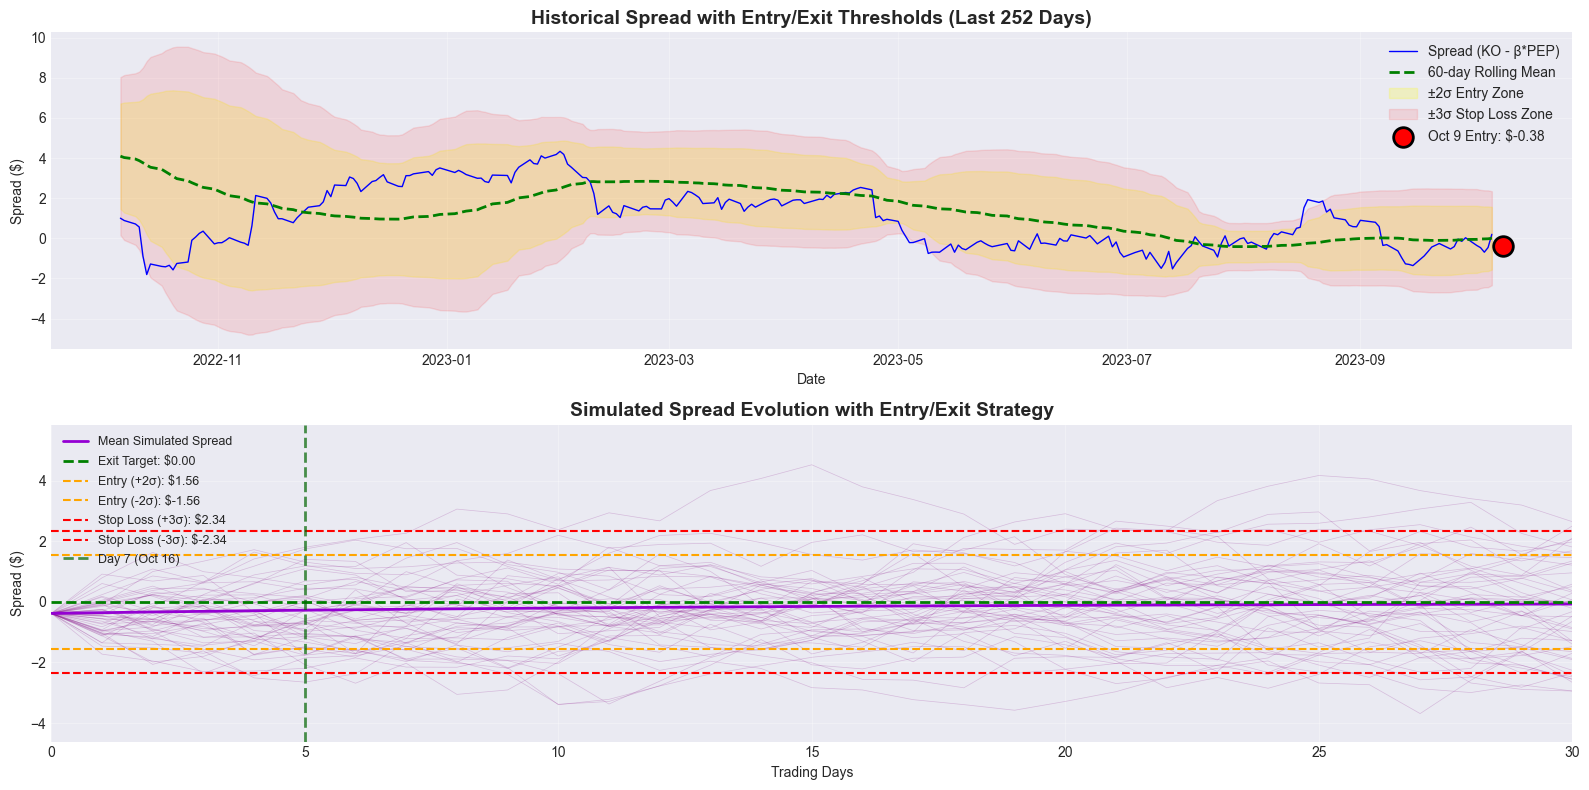

In [39]:
# Visualize Trading Strategy
fig = plt.figure(figsize=(16, 8))

# 1. Historical Spread with Entry/Exit Thresholds
ax1 = plt.subplot(2, 1, 1)
# Plot last 252 trading days (1 year)
recent_historical = spread_historical.tail(252)
plt.plot(recent_historical.index, recent_historical.values, 
         linewidth=1, color='blue', label='Spread (KO - β*PEP)')

# Rolling mean and bands
recent_rolling_mean = spread_rolling_mean.tail(252)
recent_rolling_std = spread_rolling_std.tail(252)

plt.plot(recent_rolling_mean.index, recent_rolling_mean.values, 
         color='green', linestyle='--', linewidth=2, label='60-day Rolling Mean')
plt.fill_between(recent_rolling_mean.index, 
                 recent_rolling_mean - 2*recent_rolling_std,
                 recent_rolling_mean + 2*recent_rolling_std,
                 alpha=0.2, color='yellow', label='±2σ Entry Zone')
plt.fill_between(recent_rolling_mean.index, 
                 recent_rolling_mean - 3*recent_rolling_std,
                 recent_rolling_mean + 3*recent_rolling_std,
                 alpha=0.1, color='red', label='±3σ Stop Loss Zone')

# Mark current position - convert trade_date string to datetime
trade_date_dt = pd.to_datetime(trade_date)
plt.scatter(trade_date_dt, current_spread_oct9, color='red', s=200, zorder=5, 
           marker='o', edgecolors='black', linewidths=2, label=f'Oct 9 Entry: ${current_spread_oct9:.2f}')

plt.title('Historical Spread with Entry/Exit Thresholds (Last 252 Days)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Spread ($)')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

# 2. Simulated Spread Paths with Thresholds
ax2 = plt.subplot(2, 1, 2)
n_sample_strategy = 50
sample_strategy_idx = np.random.choice(n_paths, n_sample_strategy, replace=False)
days_strategy = np.arange(n_days + 1)

for idx in sample_strategy_idx:
    plt.plot(days_strategy, spread_simulated[idx, :], alpha=0.2, linewidth=0.5, color='purple')

plt.plot(days_strategy, spread_simulated.mean(axis=0), color='darkviolet', 
         linewidth=2, label='Mean Simulated Spread')

# Entry/Exit thresholds
plt.axhline(y=exit_threshold_mean, color='green', linestyle='--', linewidth=2, 
           label=f'Exit Target: ${exit_threshold_mean:.2f}')
plt.axhline(y=entry_threshold_short_ko, color='orange', linestyle='--', linewidth=1.5, 
           label=f'Entry (+2σ): ${entry_threshold_short_ko:.2f}')
plt.axhline(y=entry_threshold_long_ko, color='orange', linestyle='--', linewidth=1.5, 
           label=f'Entry (-2σ): ${entry_threshold_long_ko:.2f}')
plt.axhline(y=stop_loss_threshold, color='red', linestyle='--', linewidth=1.5, 
           label=f'Stop Loss (+3σ): ${stop_loss_threshold:.2f}')
plt.axhline(y=spread_mean_rolling - 3*spread_std_rolling, color='red', linestyle='--', 
           linewidth=1.5, label=f'Stop Loss (-3σ): ${spread_mean_rolling - 3*spread_std_rolling:.2f}')

# Mark Day 7
plt.axvline(x=day_7_index, color='darkgreen', linestyle='--', linewidth=2, alpha=0.7, 
           label='Day 7 (Oct 16)')

plt.title('Simulated Spread Evolution with Entry/Exit Strategy', fontsize=14, fontweight='bold')
plt.xlabel('Trading Days')
plt.ylabel('Spread ($)')
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.xlim(0, 30)  # Focus on first 30 days

plt.tight_layout()
plt.show()

## 12. Enhanced Visualizations - Risk Analysis

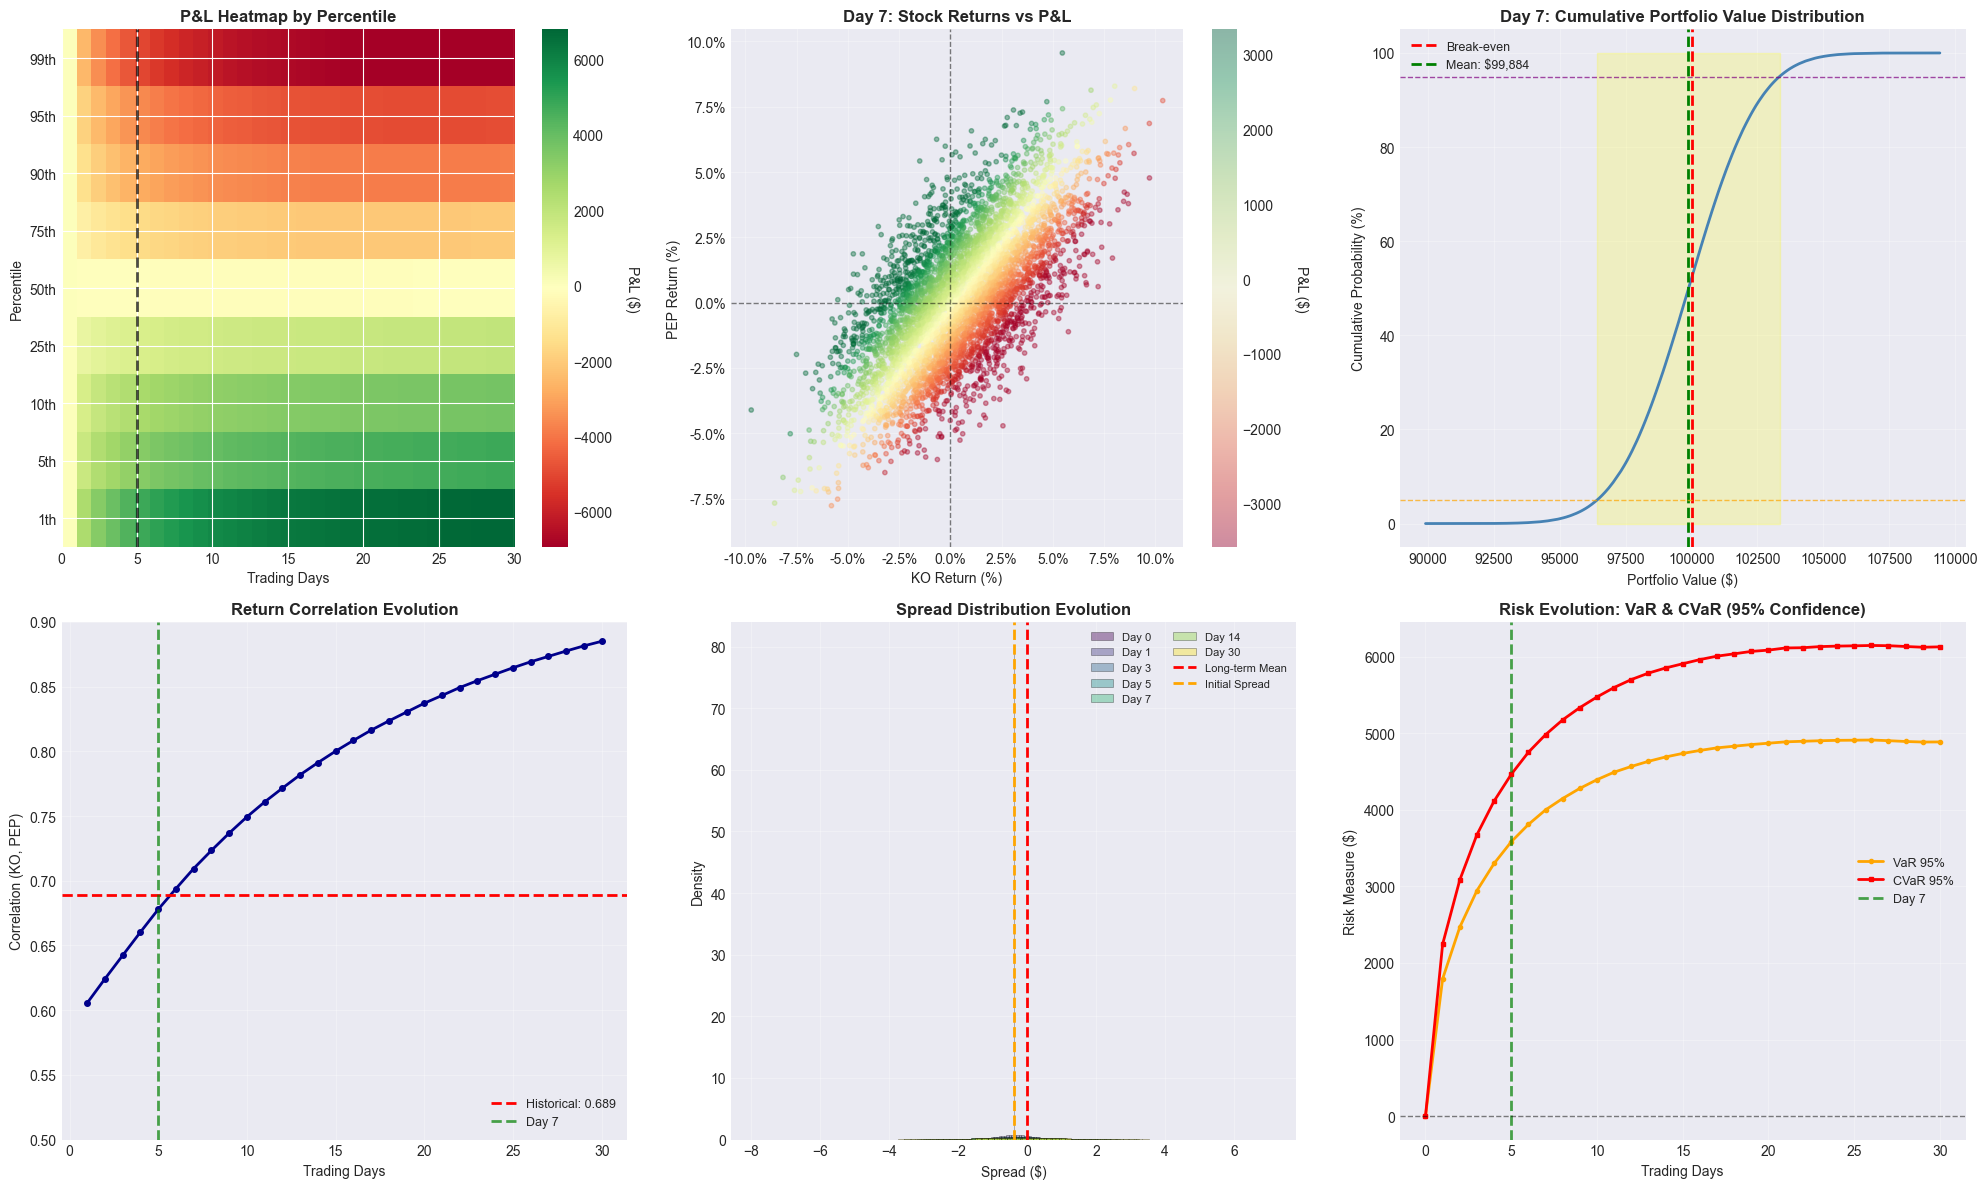

In [40]:
# Enhanced Risk Visualizations
plt.style.use('seaborn-v0_8-darkgrid')
fig = plt.figure(figsize=(20, 12))

# 1. Heatmap: P&L Distribution by Day
ax1 = plt.subplot(2, 3, 1)
days_heatmap = min(30, n_days)
pnl_percentiles = np.zeros((9, days_heatmap + 1))
percentile_levels = [1, 5, 10, 25, 50, 75, 90, 95, 99]
for i, p in enumerate(percentile_levels):
    pnl_percentiles[i, :] = np.percentile(pnl[:, :days_heatmap+1], p, axis=0)

im1 = ax1.imshow(pnl_percentiles, aspect='auto', cmap='RdYlGn', 
                 extent=[0, days_heatmap, 0, len(percentile_levels)])
ax1.set_yticks(np.arange(len(percentile_levels)) + 0.5)
ax1.set_yticklabels([f'{p}th' for p in percentile_levels])
ax1.set_xlabel('Trading Days')
ax1.set_ylabel('Percentile')
ax1.set_title('P&L Heatmap by Percentile', fontsize=12, fontweight='bold')
ax1.axvline(x=day_7_index, color='black', linestyle='--', linewidth=2, alpha=0.7)
cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label('P&L ($)', rotation=270, labelpad=20)

# 2. Day 7 P&L vs Returns Scatter with Density
ax2 = plt.subplot(2, 3, 2)
day_7_ko_returns = (ko_prices[:, day_7_index] - ko_price_trade) / ko_price_trade
day_7_pep_returns = (pep_prices[:, day_7_index] - pep_price_trade) / pep_price_trade

# Sample for visibility
sample_size = 5000
sample_idx = np.random.choice(n_paths, sample_size, replace=False)
scatter = ax2.scatter(day_7_ko_returns[sample_idx], day_7_pep_returns[sample_idx], 
                     c=day_7_pnl[sample_idx], cmap='RdYlGn', alpha=0.4, s=10, 
                     vmin=np.percentile(day_7_pnl, 5), vmax=np.percentile(day_7_pnl, 95))
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xlabel('KO Return (%)')
ax2.set_ylabel('PEP Return (%)')
ax2.set_title('Day 7: Stock Returns vs P&L', fontsize=12, fontweight='bold')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x*100:.1f}%'))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f'{y*100:.1f}%'))
cbar2 = plt.colorbar(scatter, ax=ax2)
cbar2.set_label('P&L ($)', rotation=270, labelpad=20)
ax2.grid(True, alpha=0.3)

# 3. Cumulative Portfolio Value Distribution (Day 7)
ax3 = plt.subplot(2, 3, 3)
sorted_portfolio = np.sort(day_7_portfolio_values)
cumulative_prob = np.arange(1, len(sorted_portfolio) + 1) / len(sorted_portfolio)
ax3.plot(sorted_portfolio, cumulative_prob * 100, linewidth=2, color='steelblue')
ax3.axvline(x=initial_portfolio_value, color='red', linestyle='--', linewidth=2, label='Break-even')
ax3.axvline(x=day_7_portfolio_values.mean(), color='green', linestyle='--', linewidth=2, 
           label=f'Mean: ${day_7_portfolio_values.mean():,.0f}')
ax3.axhline(y=5, color='orange', linestyle='--', linewidth=1, alpha=0.7)
ax3.axhline(y=95, color='purple', linestyle='--', linewidth=1, alpha=0.7)
ax3.fill_betweenx([0, 100], np.percentile(day_7_portfolio_values, 5), 
                  np.percentile(day_7_portfolio_values, 95), alpha=0.2, color='yellow')
ax3.set_xlabel('Portfolio Value ($)')
ax3.set_ylabel('Cumulative Probability (%)')
ax3.set_title('Day 7: Cumulative Portfolio Value Distribution', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# 4. Correlation Dynamics Over Time
ax4 = plt.subplot(2, 3, 4)
days_corr = min(30, n_days)
rolling_corr = np.zeros(days_corr + 1)
for day in range(days_corr + 1):
    ko_returns_day = (ko_prices[:, day] - ko_price_trade) / ko_price_trade
    pep_returns_day = (pep_prices[:, day] - pep_price_trade) / pep_price_trade
    rolling_corr[day] = np.corrcoef(ko_returns_day, pep_returns_day)[0, 1]

ax4.plot(np.arange(days_corr + 1), rolling_corr, linewidth=2, color='darkblue', marker='o', markersize=4)
ax4.axhline(y=correlation, color='red', linestyle='--', linewidth=2, label=f'Historical: {correlation:.3f}')
ax4.axvline(x=day_7_index, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Day 7')
ax4.set_xlabel('Trading Days')
ax4.set_ylabel('Correlation (KO, PEP)')
ax4.set_title('Return Correlation Evolution', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)
ax4.set_ylim([0.5, 0.9])

# 5. Spread Distribution Evolution
ax5 = plt.subplot(2, 3, 5)
spread_days = [0, 1, 3, 5, 7, 14, 30]
spread_days = [d for d in spread_days if d <= n_days]
colors_spread = plt.cm.viridis(np.linspace(0, 1, len(spread_days)))

for i, day in enumerate(spread_days):
    spread_day = ko_prices[:, day] - beta * pep_prices[:, day]
    ax5.hist(spread_day, bins=80, alpha=0.4, color=colors_spread[i], 
            label=f'Day {day}', density=True, edgecolor='black', linewidth=0.5)

ax5.axvline(x=spread_mean, color='red', linestyle='--', linewidth=2, label='Long-term Mean')
ax5.axvline(x=(ko_price_trade - beta * pep_price_trade), color='orange', 
           linestyle='--', linewidth=2, label='Initial Spread')
ax5.set_xlabel('Spread ($)')
ax5.set_ylabel('Density')
ax5.set_title('Spread Distribution Evolution', fontsize=12, fontweight='bold')
ax5.legend(fontsize=8, ncol=2)
ax5.grid(True, alpha=0.3)

# 6. VaR and CVaR Evolution
ax6 = plt.subplot(2, 3, 6)
days_var = min(30, n_days)
var_evolution = np.zeros(days_var + 1)
cvar_evolution = np.zeros(days_var + 1)
for day in range(days_var + 1):
    pnl_day = pnl[:, day]
    var_evolution[day] = -np.percentile(pnl_day, 5)  # VaR at 95% confidence
    cvar_evolution[day] = -pnl_day[pnl_day <= np.percentile(pnl_day, 5)].mean()

ax6.plot(np.arange(days_var + 1), var_evolution, linewidth=2, color='orange', 
        marker='o', markersize=3, label='VaR 95%')
ax6.plot(np.arange(days_var + 1), cvar_evolution, linewidth=2, color='red', 
        marker='s', markersize=3, label='CVaR 95%')
ax6.axvline(x=day_7_index, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Day 7')
ax6.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax6.set_xlabel('Trading Days')
ax6.set_ylabel('Risk Measure ($)')
ax6.set_title('Risk Evolution: VaR & CVaR (95% Confidence)', fontsize=12, fontweight='bold')
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Portfolio Performance Metrics & Beautiful Visualizations

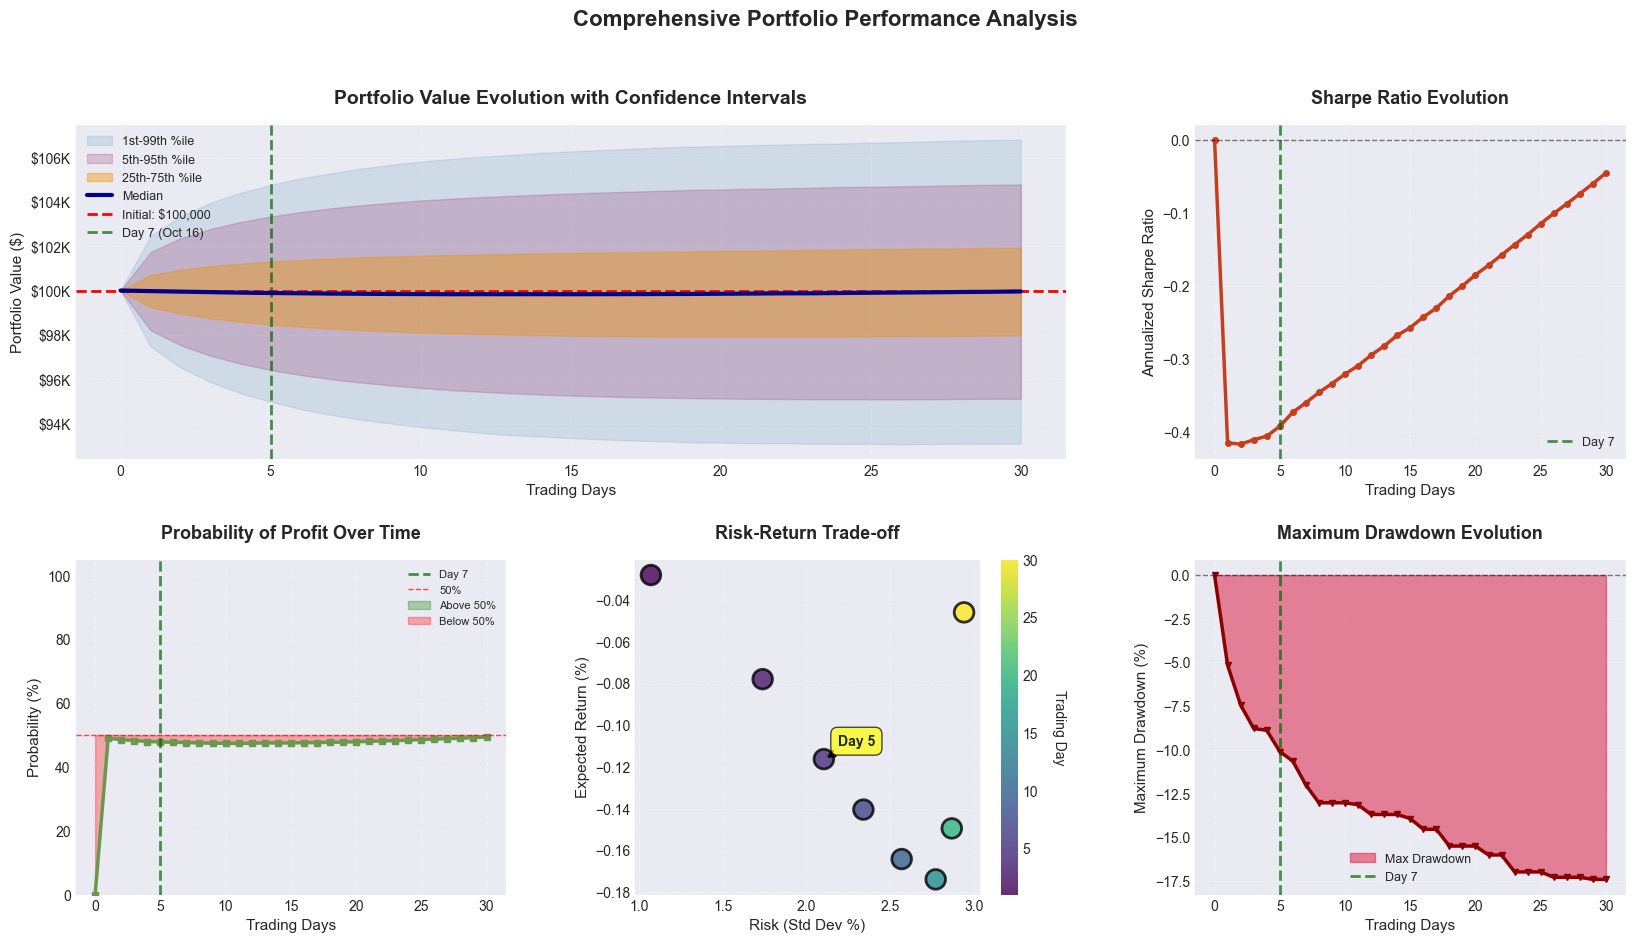


DAY 7 PERFORMANCE SUMMARY

Expected Return:        -0.12%
Volatility (Std Dev):   2.10%
Sharpe Ratio (Ann.):    -0.39
Probability of Profit:  47.9%
Max Drawdown:           -10.09%
VaR 95%:                $3,583.64
CVaR 95%:               $4,464.62


In [41]:
# Beautiful Portfolio Analysis Visualizations
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches

fig = plt.figure(figsize=(20, 10))
gs = GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)

# Custom color palette
colors_palette = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E']

# 1. Portfolio Value Fan Chart (Confidence Intervals)
ax1 = fig.add_subplot(gs[0, :2])
days_fan = min(30, n_days)
days_array = np.arange(days_fan + 1)

percentiles = [1, 5, 25, 50, 75, 95, 99]
percentile_values = np.zeros((len(percentiles), days_fan + 1))
for i, p in enumerate(percentiles):
    percentile_values[i, :] = np.percentile(portfolio_values[:, :days_fan+1], p, axis=0)

# Plot confidence bands
ax1.fill_between(days_array, percentile_values[0, :], percentile_values[6, :], 
                alpha=0.15, color=colors_palette[0], label='1st-99th %ile')
ax1.fill_between(days_array, percentile_values[1, :], percentile_values[5, :], 
                alpha=0.25, color=colors_palette[1], label='5th-95th %ile')
ax1.fill_between(days_array, percentile_values[2, :], percentile_values[4, :], 
                alpha=0.4, color=colors_palette[2], label='25th-75th %ile')
ax1.plot(days_array, percentile_values[3, :], linewidth=3, color='darkblue', 
        label='Median', zorder=10)
ax1.axhline(y=initial_portfolio_value, color='red', linestyle='--', linewidth=2, 
           label=f'Initial: ${initial_portfolio_value:,.0f}')
ax1.axvline(x=day_7_index, color='darkgreen', linestyle='--', linewidth=2, 
           alpha=0.7, label='Day 7 (Oct 16)')

ax1.set_xlabel('Trading Days', fontsize=11)
ax1.set_ylabel('Portfolio Value ($)', fontsize=11)
ax1.set_title('Portfolio Value Evolution with Confidence Intervals', 
             fontsize=14, fontweight='bold', pad=15)
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# 2. Sharpe Ratio Evolution
ax2 = fig.add_subplot(gs[0, 2])
days_sharpe = min(30, n_days)
sharpe_ratios = np.zeros(days_sharpe + 1)
for day in range(1, days_sharpe + 1):
    returns_day = (portfolio_values[:, day] - initial_portfolio_value) / initial_portfolio_value
    sharpe_ratios[day] = returns_day.mean() / returns_day.std() * np.sqrt(252 / day)

sharpe_ratios[0] = 0  # No Sharpe ratio at day 0

ax2.plot(np.arange(days_sharpe + 1), sharpe_ratios, linewidth=2.5, 
        color=colors_palette[3], marker='o', markersize=4)
ax2.axvline(x=day_7_index, color='darkgreen', linestyle='--', linewidth=2, 
           alpha=0.7, label='Day 7')
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xlabel('Trading Days', fontsize=11)
ax2.set_ylabel('Annualized Sharpe Ratio', fontsize=11)
ax2.set_title('Sharpe Ratio Evolution', fontsize=13, fontweight='bold', pad=15)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, linestyle='--')

# 3. Probability of Profit Over Time
ax3 = fig.add_subplot(gs[1, 0])
days_prob = min(30, n_days)
prob_profit = np.zeros(days_prob + 1)
for day in range(days_prob + 1):
    prob_profit[day] = (pnl[:, day] > 0).mean() * 100

ax3.plot(np.arange(days_prob + 1), prob_profit, linewidth=2.5, 
        color=colors_palette[4], marker='s', markersize=4)
ax3.axvline(x=day_7_index, color='darkgreen', linestyle='--', linewidth=2, 
           alpha=0.7, label='Day 7')
ax3.axhline(y=50, color='red', linestyle='--', linewidth=1, alpha=0.7, label='50%')
ax3.fill_between(np.arange(days_prob + 1), 50, prob_profit, 
                where=(prob_profit >= 50), alpha=0.3, color='green', 
                interpolate=True, label='Above 50%')
ax3.fill_between(np.arange(days_prob + 1), prob_profit, 50, 
                where=(prob_profit < 50), alpha=0.3, color='red', 
                interpolate=True, label='Below 50%')
ax3.set_xlabel('Trading Days', fontsize=11)
ax3.set_ylabel('Probability (%)', fontsize=11)
ax3.set_title('Probability of Profit Over Time', fontsize=13, fontweight='bold', pad=15)
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_ylim([0, 105])

# 4. Expected Return vs Risk (Return-Risk Scatter)
ax4 = fig.add_subplot(gs[1, 1])
days_scatter = [1, 3, 5, 7, 10, 15, 20, 30]
days_scatter = [d for d in days_scatter if d <= n_days]
expected_returns = []
risk_std = []

for day in days_scatter:
    returns_day = (portfolio_values[:, day] - initial_portfolio_value) / initial_portfolio_value
    expected_returns.append(returns_day.mean() * 100)
    risk_std.append(returns_day.std() * 100)

scatter = ax4.scatter(risk_std, expected_returns, s=200, c=days_scatter, 
                     cmap='viridis', edgecolors='black', linewidths=2, alpha=0.8)

# Annotate day 7
day_7_idx = days_scatter.index(day_7_index) if day_7_index in days_scatter else None
if day_7_idx is not None:
    ax4.annotate(f'Day {day_7_index}', 
                xy=(risk_std[day_7_idx], expected_returns[day_7_idx]),
                xytext=(10, 10), textcoords='offset points',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', lw=2))

ax4.set_xlabel('Risk (Std Dev %)', fontsize=11)
ax4.set_ylabel('Expected Return (%)', fontsize=11)
ax4.set_title('Risk-Return Trade-off', fontsize=13, fontweight='bold', pad=15)
ax4.grid(True, alpha=0.3, linestyle='--')
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('Trading Day', rotation=270, labelpad=20)

# 5. Maximum Drawdown Over Time
ax5 = fig.add_subplot(gs[1, 2])
days_dd = min(30, n_days)
max_drawdown = np.zeros(days_dd + 1)

for day in range(days_dd + 1):
    portfolio_cummax = np.maximum.accumulate(portfolio_values[:, :day+1], axis=1)
    drawdown = (portfolio_values[:, :day+1] - portfolio_cummax) / portfolio_cummax
    max_drawdown[day] = drawdown.min() * 100

ax5.fill_between(np.arange(days_dd + 1), max_drawdown, 0, 
                alpha=0.5, color='crimson', label='Max Drawdown')
ax5.plot(np.arange(days_dd + 1), max_drawdown, linewidth=2.5, 
        color='darkred', marker='v', markersize=4)
ax5.axvline(x=day_7_index, color='darkgreen', linestyle='--', linewidth=2, 
           alpha=0.7, label='Day 7')
ax5.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax5.set_xlabel('Trading Days', fontsize=11)
ax5.set_ylabel('Maximum Drawdown (%)', fontsize=11)
ax5.set_title('Maximum Drawdown Evolution', fontsize=13, fontweight='bold', pad=15)
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3, linestyle='--')

plt.suptitle('Comprehensive Portfolio Performance Analysis', 
            fontsize=16, fontweight='bold', y=0.995)
plt.show()

# Print Day 7 Performance Summary
print("\n" + "=" * 80)
print("DAY 7 PERFORMANCE SUMMARY")
print("=" * 80)
print(f"\nExpected Return:        {expected_return_day7:.2%}")
print(f"Volatility (Std Dev):   {return_std_day7:.2%}")
print(f"Sharpe Ratio (Ann.):    {sharpe_ratios[day_7_index]:.2f}")
print(f"Probability of Profit:  {prob_profit[day_7_index]:.1f}%")
print(f"Max Drawdown:           {max_drawdown[day_7_index]:.2f}%")
print(f"VaR 95%:                ${var_95_day7:,.2f}")
print(f"CVaR 95%:               ${cvar_95_day7:,.2f}")
print("=" * 80)

## 14. Mean-Reversion Trading Strategy on 60-Day Simulations

Implement and test a z-score based mean-reversion strategy on the simulated price paths.

In [42]:
# Trading Strategy Implementation on 60-Day Simulations
print("=" * 80)
print("60-DAY SIMULATED TRADING STRATEGY")
print("=" * 80)

# Strategy parameters
strategy_entry_threshold = 1.5  # Entry when |z-score| > 1.5
strategy_exit_threshold = 0.2   # Exit when |z-score| < 0.2 (near mean)
strategy_stop_loss = 2.5        # Stop loss when |z-score| > 2.5

# Calculate z-scores for all simulated paths
spread_all = ko_prices - beta * pep_prices
z_scores = (spread_all - spread_mean) / spread_std

# Initialize tracking arrays
positions = np.zeros((n_paths, n_days + 1), dtype=int)  # 0=no position, 1=long spread, -1=short spread
strategy_pnl = np.zeros(n_paths)
trade_count = np.zeros(n_paths)
entry_days = np.full(n_paths, -1)
exit_days = np.full(n_paths, -1)

# Execute strategy for each path
for path in range(n_paths):
    position = 0
    entry_day = -1
    entry_ko_price = 0
    entry_pep_price = 0
    
    for day in range(1, n_days + 1):
        z = z_scores[path, day]
        
        if position == 0:
            # Entry signals
            if z < -strategy_entry_threshold:
                position = 1  # Long spread (buy KO, short PEP)
                entry_ko_price = ko_prices[path, day]
                entry_pep_price = pep_prices[path, day]
                entry_day = day
                trade_count[path] += 1
            elif z > strategy_entry_threshold:
                position = -1  # Short spread (sell KO, buy PEP)
                entry_ko_price = ko_prices[path, day]
                entry_pep_price = pep_prices[path, day]
                entry_day = day
                trade_count[path] += 1
        
        else:
            # Exit signals: mean reversion or stop loss
            exit_signal = abs(z) < strategy_exit_threshold or abs(z) > strategy_stop_loss
            
            if exit_signal:
                # Calculate P&L for this trade
                exit_ko_price = ko_prices[path, day]
                exit_pep_price = pep_prices[path, day]
                
                # P&L calculation for spread trading
                # position == 1 means "Long Spread" (long KO, short PEP)
                # position == -1 means "Short Spread" (short KO, long PEP)
                if position == 1:  # Long spread: profit when KO rises OR PEP falls
                    pnl_trade = (exit_ko_price - entry_ko_price) * ko_shares - \
                               (exit_pep_price - entry_pep_price) * pep_shares
                else:  # Short spread: profit when KO falls OR PEP rises  
                    pnl_trade = -(exit_ko_price - entry_ko_price) * ko_shares + \
                               (exit_pep_price - entry_pep_price) * pep_shares
                
                strategy_pnl[path] += pnl_trade
                
                # Record exit
                if exit_days[path] == -1:  # Record first exit
                    exit_days[path] = day
                    entry_days[path] = entry_day
                
                position = 0
        
        positions[path, day] = position

# Calculate final P&L for paths still holding positions at day 60
for path in range(n_paths):
    if positions[path, n_days] != 0:
        # Find entry day for this path
        entry_day_idx = -1
        for day in range(1, n_days + 1):
            if positions[path, day] != 0 and positions[path, day-1] == 0:
                entry_day_idx = day
                break
        
        if entry_day_idx > 0:
            entry_ko_price = ko_prices[path, entry_day_idx]
            entry_pep_price = pep_prices[path, entry_day_idx]
            exit_ko_price = ko_prices[path, n_days]
            exit_pep_price = pep_prices[path, n_days]
            
            # Calculate final P&L for unclosed position
            if positions[path, n_days] == 1:  # Long spread
                pnl_trade = (exit_ko_price - entry_ko_price) * ko_shares - \
                           (exit_pep_price - entry_pep_price) * pep_shares
            else:  # Short spread
                pnl_trade = -(exit_ko_price - entry_ko_price) * ko_shares + \
                           (exit_pep_price - entry_pep_price) * pep_shares
            
            strategy_pnl[path] += pnl_trade

# Performance metrics
winning_trades = strategy_pnl > 0
losing_trades = strategy_pnl < 0

win_rate = winning_trades.mean() * 100
avg_win = strategy_pnl[winning_trades].mean() if winning_trades.any() else 0
avg_loss = strategy_pnl[losing_trades].mean() if losing_trades.any() else 0
profit_factor = abs(avg_win / avg_loss) if avg_loss != 0 else 0
max_gain = strategy_pnl.max()
max_loss = strategy_pnl.min()
median_pnl = np.median(strategy_pnl)

# Sharpe ratio for strategy
strategy_returns = strategy_pnl / initial_capital
mean_return = strategy_returns.mean()
std_return = strategy_returns.std()
sharpe_strategy = (mean_return / std_return) * np.sqrt(252 / 60) if std_return != 0 else 0

print(f"\nStrategy Performance (60-Day Simulation, {n_paths:,} paths):")
print(f"  Win rate:                {win_rate:.1f}%")
print(f"  Average winning trade:   ${avg_win:,.2f}")
print(f"  Average losing trade:    ${avg_loss:,.2f}")
print(f"  Profit factor:           {profit_factor:.2f}")
print(f"  Max gain:                ${max_gain:,.2f}")
print(f"  Max loss:                ${max_loss:,.2f}")
print(f"  Median P&L:              ${median_pnl:,.2f}")
print(f"  Sharpe ratio:            {sharpe_strategy:.2f}")
print(f"  Probability of profit:   {win_rate:.1f}%")
print(f"  Paths with trades:       {(trade_count > 0).sum():,} ({(trade_count > 0).mean()*100:.1f}%)")
print("=" * 80)

60-DAY SIMULATED TRADING STRATEGY

Strategy Performance (60-Day Simulation, 1,000,000 paths):
  Win rate:                70.1%
  Average winning trade:   $5,778.09
  Average losing trade:    $-3,731.65
  Profit factor:           1.55
  Max gain:                $34,213.62
  Max loss:                $-26,966.48
  Median P&L:              $3,047.37
  Sharpe ratio:            1.05
  Probability of profit:   70.1%
  Paths with trades:       999,707 (100.0%)

Strategy Performance (60-Day Simulation, 1,000,000 paths):
  Win rate:                70.1%
  Average winning trade:   $5,778.09
  Average losing trade:    $-3,731.65
  Profit factor:           1.55
  Max gain:                $34,213.62
  Max loss:                $-26,966.48
  Median P&L:              $3,047.37
  Sharpe ratio:            1.05
  Probability of profit:   70.1%
  Paths with trades:       999,707 (100.0%)


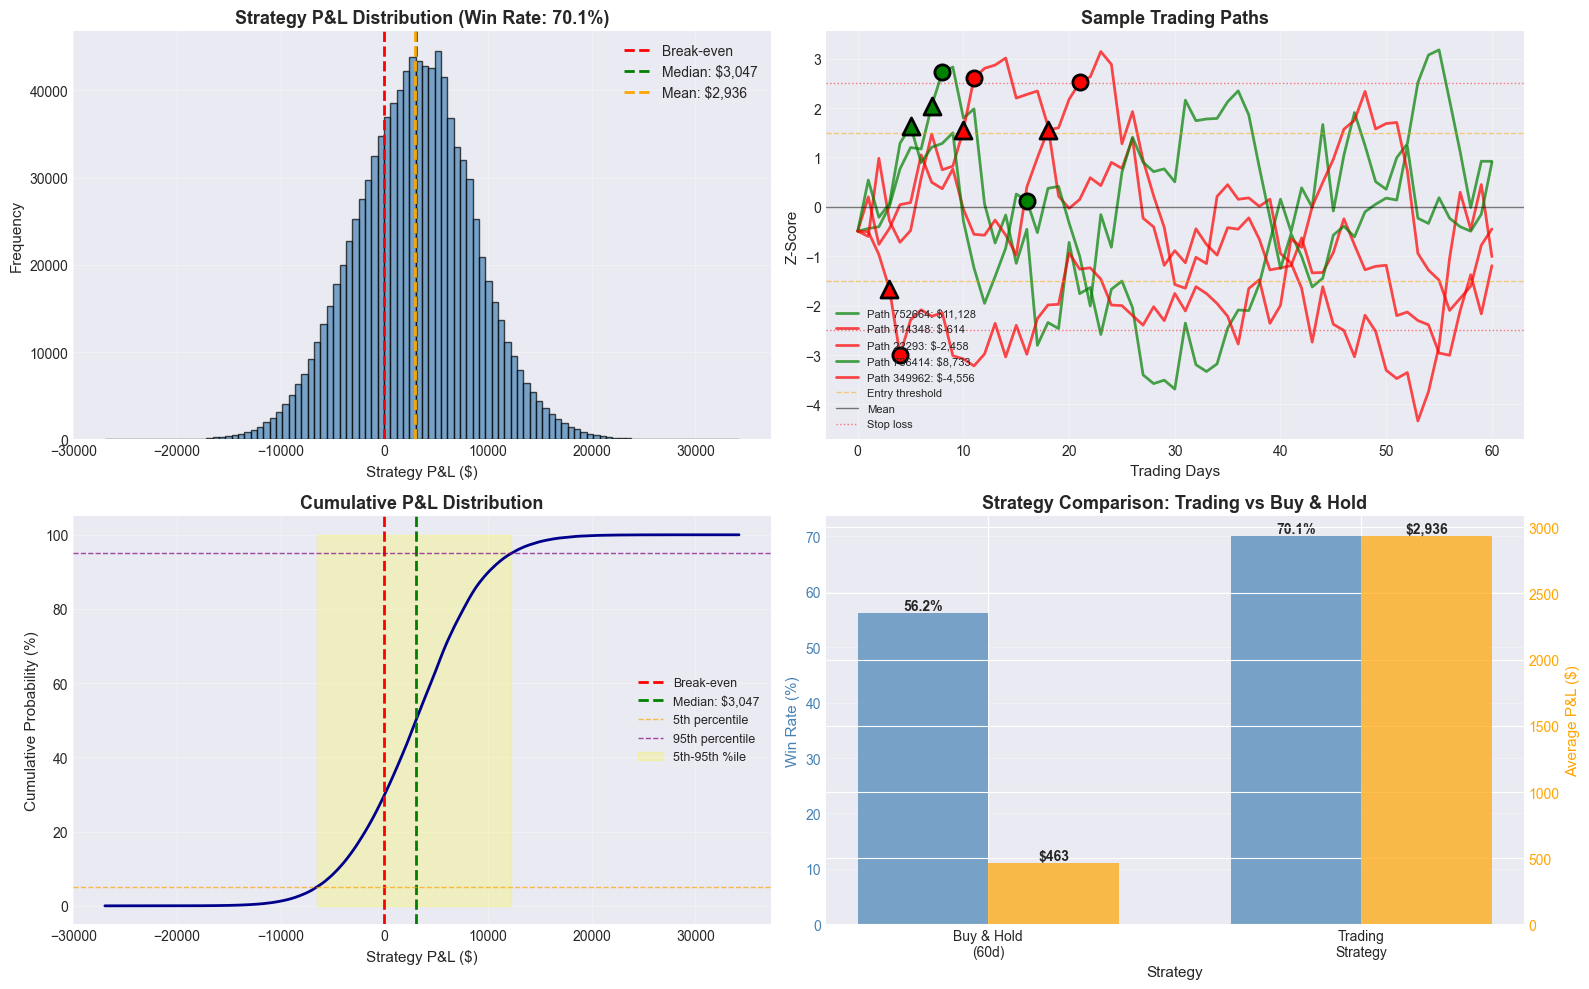


Strategy visualization complete!


In [43]:
# Visualize Strategy Results
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Strategy P&L Distribution
ax1 = axes[0, 0]
ax1.hist(strategy_pnl, bins=100, color='steelblue', alpha=0.7, edgecolor='black')
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Break-even')
ax1.axvline(x=median_pnl, color='green', linestyle='--', linewidth=2, label=f'Median: ${median_pnl:,.0f}')
ax1.axvline(x=strategy_pnl.mean(), color='orange', linestyle='--', linewidth=2, 
           label=f'Mean: ${strategy_pnl.mean():,.0f}')
ax1.set_xlabel('Strategy P&L ($)', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title(f'Strategy P&L Distribution (Win Rate: {win_rate:.1f}%)', 
             fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 2. Sample Trading Paths
ax2 = axes[0, 1]
n_sample = 5
sample_idx = np.random.choice(np.where(trade_count > 0)[0], min(n_sample, (trade_count > 0).sum()), replace=False)
colors_sample = ['green' if strategy_pnl[i] > 0 else 'red' for i in sample_idx]

for i, idx in enumerate(sample_idx):
    ax2.plot(np.arange(n_days + 1), z_scores[idx, :], linewidth=2, alpha=0.7, 
            color=colors_sample[i], label=f'Path {idx}: ${strategy_pnl[idx]:,.0f}')
    
    # Mark entry and exit
    if entry_days[idx] > 0:
        ax2.scatter(entry_days[idx], z_scores[idx, entry_days[idx]], marker='^', 
                   s=150, color=colors_sample[i], edgecolors='black', linewidths=2, zorder=5)
    if exit_days[idx] > 0:
        ax2.scatter(exit_days[idx], z_scores[idx, exit_days[idx]], marker='o', 
                   s=120, color=colors_sample[i], edgecolors='black', linewidths=2, zorder=5)

ax2.axhline(y=strategy_entry_threshold, color='orange', linestyle='--', linewidth=1, alpha=0.5, 
           label='Entry threshold')
ax2.axhline(y=-strategy_entry_threshold, color='orange', linestyle='--', linewidth=1, alpha=0.5)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5, label='Mean')
ax2.axhline(y=strategy_stop_loss, color='red', linestyle=':', linewidth=1, alpha=0.5, label='Stop loss')
ax2.axhline(y=-strategy_stop_loss, color='red', linestyle=':', linewidth=1, alpha=0.5)
ax2.set_xlabel('Trading Days', fontsize=11)
ax2.set_ylabel('Z-Score', fontsize=11)
ax2.set_title('Sample Trading Paths', fontsize=13, fontweight='bold')
ax2.legend(fontsize=8, loc='best')
ax2.grid(True, alpha=0.3)

# 3. Cumulative P&L Distribution
ax3 = axes[1, 0]
sorted_pnl = np.sort(strategy_pnl)
cumulative_prob = np.arange(1, len(sorted_pnl) + 1) / len(sorted_pnl)
ax3.plot(sorted_pnl, cumulative_prob * 100, linewidth=2, color='darkblue')
ax3.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Break-even')
ax3.axvline(x=median_pnl, color='green', linestyle='--', linewidth=2, label=f'Median: ${median_pnl:,.0f}')
ax3.axhline(y=5, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='5th percentile')
ax3.axhline(y=95, color='purple', linestyle='--', linewidth=1, alpha=0.7, label='95th percentile')
ax3.fill_betweenx([0, 100], np.percentile(strategy_pnl, 5), np.percentile(strategy_pnl, 95), 
                  alpha=0.2, color='yellow', label='5th-95th %ile')
ax3.set_xlabel('Strategy P&L ($)', fontsize=11)
ax3.set_ylabel('Cumulative Probability (%)', fontsize=11)
ax3.set_title('Cumulative P&L Distribution', fontsize=13, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# 4. Win Rate vs Number of Trades
ax4 = axes[1, 1]
# Compare strategy vs buy-and-hold at 60 days
comparison_data = {
    'Buy & Hold\n(60d)': [(pnl[:, n_days] > 0).mean() * 100, pnl[:, n_days].mean()],
    'Trading\nStrategy': [win_rate, strategy_pnl.mean()]
}
labels = list(comparison_data.keys())
win_rates = [comparison_data[k][0] for k in labels]
avg_pnls = [comparison_data[k][1] for k in labels]

x = np.arange(len(labels))
width = 0.35

bars1 = ax4.bar(x - width/2, win_rates, width, label='Win Rate (%)', color='steelblue', alpha=0.7)
ax4_twin = ax4.twinx()
bars2 = ax4_twin.bar(x + width/2, avg_pnls, width, label='Avg P&L ($)', color='orange', alpha=0.7)

ax4.set_xlabel('Strategy', fontsize=11)
ax4.set_ylabel('Win Rate (%)', fontsize=11, color='steelblue')
ax4_twin.set_ylabel('Average P&L ($)', fontsize=11, color='orange')
ax4.set_title('Strategy Comparison: Trading vs Buy & Hold', fontsize=13, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(labels)
ax4.tick_params(axis='y', labelcolor='steelblue')
ax4_twin.tick_params(axis='y', labelcolor='orange')
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    ax4_twin.text(bar.get_x() + bar.get_width()/2., height,
                 f'${height:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nStrategy visualization complete!")

In [49]:
# Extract 60-day statistics for blog
print("=" * 80)
print("60-DAY PORTFOLIO STATISTICS FOR BLOG")
print("=" * 80)

# Portfolio values at day 60
final_portfolio = portfolio_values[:, 60]

# VaR calculations
var_90 = np.percentile(final_portfolio, 10)
var_95 = np.percentile(final_portfolio, 5)
var_99 = np.percentile(final_portfolio, 1)

# CVaR calculation
var_threshold_95 = np.percentile(final_portfolio, 5)
cvar_95 = final_portfolio[final_portfolio <= var_threshold_95].mean()

# Portfolio distribution percentiles
p1 = np.percentile(final_portfolio, 1)
p5 = np.percentile(final_portfolio, 5)
p50 = np.percentile(final_portfolio, 50)
p95 = np.percentile(final_portfolio, 95)
p99 = np.percentile(final_portfolio, 99)

print(f"\n60-Day Portfolio Value Distribution:")
print(f"  1st percentile:   ${p1:,.2f}")
print(f"  5th percentile:   ${p5:,.2f} (VaR 95%)")
print(f"  Median:           ${p50:,.2f}")
print(f"  95th percentile:  ${p95:,.2f}")
print(f"  99th percentile:  ${p99:,.2f}")

print(f"\n60-Day VaR Results:")
print(f"  VaR 90%: ${var_90:,.2f} (loss: ${initial_capital - var_90:,.2f})")
print(f"  VaR 95%: ${var_95:,.2f} (loss: ${initial_capital - var_95:,.2f})")
print(f"  VaR 99%: ${var_99:,.2f} (loss: ${initial_capital - var_99:,.2f})")

print(f"\n60-Day CVaR:")
print(f"  CVaR 95%: ${cvar_95:,.2f} (avg loss in worst 5%: ${initial_capital - cvar_95:,.2f})")

# Maximum drawdown
portfolio_cummax = np.maximum.accumulate(portfolio_values, axis=1)
drawdown_all = (portfolio_values - portfolio_cummax) / portfolio_cummax
max_dd_per_path = drawdown_all.min(axis=1)

print(f"\nMaximum Drawdown Statistics:")
print(f"  Average max drawdown: {max_dd_per_path.mean()*100:.2f}%")
print(f"  Median max drawdown:  {np.median(max_dd_per_path)*100:.2f}%")
print(f"  Worst drawdown:       {max_dd_per_path.min()*100:.2f}%")

# Sharpe ratio for buy-and-hold
returns_60d = (final_portfolio - initial_capital) / initial_capital
mean_ret = returns_60d.mean()
std_ret = returns_60d.std()
sharpe_bh = (mean_ret / std_ret) * np.sqrt(252 / 60)

print(f"\nBuy-and-Hold Performance:")
print(f"  Expected return:  {mean_ret*100:.2f}%")
print(f"  Std deviation:    {std_ret*100:.2f}%")
print(f"  Sharpe ratio:     {sharpe_bh:.2f}")

print("=" * 80)

60-DAY PORTFOLIO STATISTICS FOR BLOG

60-Day Portfolio Value Distribution:
  1st percentile:   $93,469.84
  5th percentile:   $95,541.11 (VaR 95%)
  Median:           $100,467.90
  95th percentile:  $105,383.46
  99th percentile:  $107,469.50

60-Day VaR Results:
  VaR 90%: $96,636.74 (loss: $3,363.26)
  VaR 95%: $95,541.11 (loss: $4,458.89)
  VaR 99%: $93,469.84 (loss: $6,530.16)

60-Day CVaR:
  CVaR 95%: $94,269.89 (avg loss in worst 5%: $5,730.11)

Maximum Drawdown Statistics:
  Average max drawdown: -7.38%
  Median max drawdown:  -7.15%
  Worst drawdown:       -20.99%

Buy-and-Hold Performance:
  Expected return:  0.46%
  Std deviation:    2.99%
  Sharpe ratio:     0.32


## 15. Real-World Strategy Backtest (2-Year Historical Data)

Test the mean-reversion strategy using actual market data from October 2023 to October 2025.

## Comparison of VaR Methods: Historical Simulation vs Monte Carlo vs Parametric

We'll compare three standard approaches to calculate Value at Risk (VaR) over the 60-day period:

1. **Historical Simulation**: Uses actual historical returns to estimate portfolio loss distribution
2. **Monte Carlo Simulation**: Already computed above using simulated price paths
3. **Parametric (Variance-Covariance)**: Assumes normal distribution of returns

In [54]:
# Calculate VaR using three methods for 60-day horizon

# Method 1: Monte Carlo (already computed above)
mc_var_90 = initial_capital - var_90
mc_var_95 = initial_capital - var_95
mc_var_99 = initial_capital - var_99

# Method 2: Historical Simulation
# Use actual historical returns over rolling 60-day windows
ko_hist_returns = historical_data['KO'].pct_change().dropna()
pep_hist_returns = historical_data['PEP'].pct_change().dropna()

# Create historical portfolio returns (short KO, long PEP)
historical_portfolio_returns = -ko_hist_returns + pep_hist_returns

# Simulate 60-day cumulative returns using bootstrap with replacement
n_bootstrap = 1000000
hist_sim_returns = np.zeros(n_bootstrap)

np.random.seed(42)
for i in range(n_bootstrap):
    # Sample 60 daily returns with replacement
    sampled_returns = np.random.choice(historical_portfolio_returns.values, size=60, replace=True)
    # Calculate cumulative return
    hist_sim_returns[i] = np.prod(1 + sampled_returns) - 1

# Calculate portfolio values from historical simulation
hist_sim_portfolio = initial_capital * (1 + hist_sim_returns)

# Historical Simulation VaR
hist_var_90 = initial_capital - np.percentile(hist_sim_portfolio, 10)
hist_var_95 = initial_capital - np.percentile(hist_sim_portfolio, 5)
hist_var_99 = initial_capital - np.percentile(hist_sim_portfolio, 1)

# Method 3: Parametric (Variance-Covariance) Method
# Assumes returns are normally distributed
portfolio_std_daily = historical_portfolio_returns.std()
portfolio_mean_daily = historical_portfolio_returns.mean()

# Scale to 60-day horizon
portfolio_mean_60d = portfolio_mean_daily * 60
portfolio_std_60d = portfolio_std_daily * np.sqrt(60)

# Calculate VaR using normal distribution quantiles
from scipy import stats
z_90 = stats.norm.ppf(0.10)  # 10th percentile
z_95 = stats.norm.ppf(0.05)  # 5th percentile
z_99 = stats.norm.ppf(0.01)  # 1st percentile

# Parametric portfolio values at confidence levels
param_portfolio_90 = initial_capital * (1 + portfolio_mean_60d + z_90 * portfolio_std_60d)
param_portfolio_95 = initial_capital * (1 + portfolio_mean_60d + z_95 * portfolio_std_60d)
param_portfolio_99 = initial_capital * (1 + portfolio_mean_60d + z_99 * portfolio_std_60d)

# Parametric VaR
param_var_90 = initial_capital - param_portfolio_90
param_var_95 = initial_capital - param_portfolio_95
param_var_99 = initial_capital - param_portfolio_99

print("=" * 80)
print("VaR COMPARISON: THREE METHODS (60-Day Horizon)")
print("=" * 80)

print("\nVaR 90% (10th percentile):")
print(f"  Monte Carlo:          ${mc_var_90:,.2f}")
print(f"  Historical Simulation: ${hist_var_90:,.2f}")
print(f"  Parametric (VCV):     ${param_var_90:,.2f}")

print("\nVaR 95% (5th percentile):")
print(f"  Monte Carlo:          ${mc_var_95:,.2f}")
print(f"  Historical Simulation: ${hist_var_95:,.2f}")
print(f"  Parametric (VCV):     ${param_var_95:,.2f}")

print("\nVaR 99% (1st percentile):")
print(f"  Monte Carlo:          ${mc_var_99:,.2f}")
print(f"  Historical Simulation: ${hist_var_99:,.2f}")
print(f"  Parametric (VCV):     ${param_var_99:,.2f}")

# Calculate percentage differences from Monte Carlo (baseline)
print("\n" + "=" * 80)
print("DIFFERENCE FROM MONTE CARLO (baseline)")
print("=" * 80)

print("\nVaR 90%:")
print(f"  Historical Simulation: {(hist_var_90 - mc_var_90) / mc_var_90 * 100:+.2f}%")
print(f"  Parametric (VCV):     {(param_var_90 - mc_var_90) / mc_var_90 * 100:+.2f}%")

print("\nVaR 95%:")
print(f"  Historical Simulation: {(hist_var_95 - mc_var_95) / mc_var_95 * 100:+.2f}%")
print(f"  Parametric (VCV):     {(param_var_95 - mc_var_95) / mc_var_95 * 100:+.2f}%")

print("\nVaR 99%:")
print(f"  Historical Simulation: {(hist_var_99 - mc_var_99) / mc_var_99 * 100:+.2f}%")
print(f"  Parametric (VCV):     {(param_var_99 - mc_var_99) / mc_var_99 * 100:+.2f}%")

print("=" * 80)

VaR COMPARISON: THREE METHODS (60-Day Horizon)

VaR 90% (10th percentile):
  Monte Carlo:          $3,363.26
  Historical Simulation: $8,354.61
  Parametric (VCV):     $8,561.79

VaR 95% (5th percentile):
  Monte Carlo:          $4,458.89
  Historical Simulation: $10,716.76
  Parametric (VCV):     $11,094.76

VaR 99% (1st percentile):
  Monte Carlo:          $6,530.16
  Historical Simulation: $15,072.63
  Parametric (VCV):     $15,846.19

DIFFERENCE FROM MONTE CARLO (baseline)

VaR 90%:
  Historical Simulation: +148.41%
  Parametric (VCV):     +154.57%

VaR 95%:
  Historical Simulation: +140.35%
  Parametric (VCV):     +148.82%

VaR 99%:
  Historical Simulation: +130.82%
  Parametric (VCV):     +142.66%


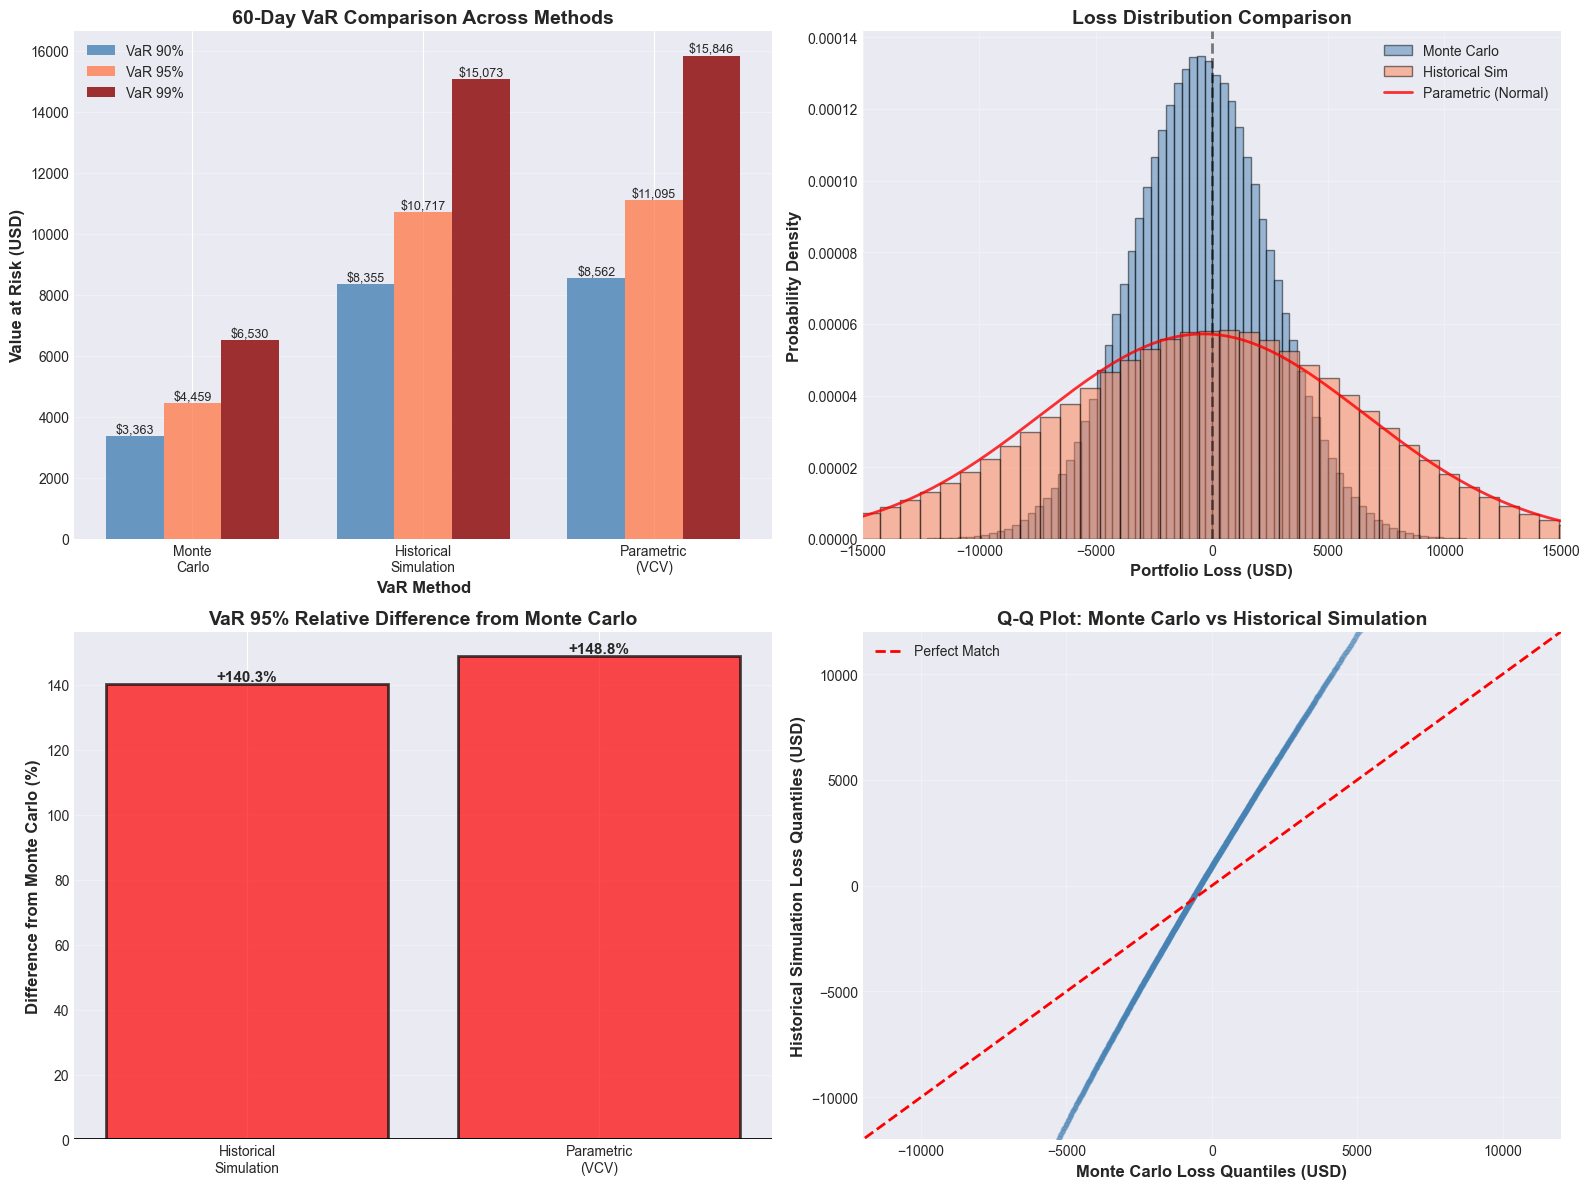

VaR comparison visualization complete!


In [55]:
# Visualize VaR comparison across three methods
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. VaR Comparison Bar Chart
ax1 = axes[0, 0]
methods = ['Monte\nCarlo', 'Historical\nSimulation', 'Parametric\n(VCV)']
var_90_values = [mc_var_90, hist_var_90, param_var_90]
var_95_values = [mc_var_95, hist_var_95, param_var_95]
var_99_values = [mc_var_99, hist_var_99, param_var_99]

x = np.arange(len(methods))
width = 0.25

bars1 = ax1.bar(x - width, var_90_values, width, label='VaR 90%', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x, var_95_values, width, label='VaR 95%', color='coral', alpha=0.8)
bars3 = ax1.bar(x + width, var_99_values, width, label='VaR 99%', color='darkred', alpha=0.8)

ax1.set_xlabel('VaR Method', fontsize=12, fontweight='bold')
ax1.set_ylabel('Value at Risk (USD)', fontsize=12, fontweight='bold')
ax1.set_title('60-Day VaR Comparison Across Methods', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(methods)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'${height:,.0f}', ha='center', va='bottom', fontsize=9)

# 2. Distribution Comparison
ax2 = axes[0, 1]
ax2.hist(initial_capital - final_portfolio, bins=100, density=True, 
         alpha=0.5, label='Monte Carlo', color='steelblue', edgecolor='black')
ax2.hist(initial_capital - hist_sim_portfolio, bins=100, density=True,
         alpha=0.5, label='Historical Sim', color='coral', edgecolor='black')

# Add parametric distribution
x_range = np.linspace(-20000, 20000, 1000)
param_pdf = stats.norm.pdf(x_range, 
                           loc=-portfolio_mean_60d * initial_capital,
                           scale=portfolio_std_60d * initial_capital)
ax2.plot(x_range, param_pdf, 'r-', linewidth=2, label='Parametric (Normal)', alpha=0.8)

ax2.axvline(x=0, color='black', linestyle='--', linewidth=2, alpha=0.5)
ax2.set_xlabel('Portfolio Loss (USD)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
ax2.set_title('Loss Distribution Comparison', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-15000, 15000)

# 3. VaR 95% Relative Differences
ax3 = axes[1, 0]
var_95_diff_hist = (hist_var_95 - mc_var_95) / mc_var_95 * 100
var_95_diff_param = (param_var_95 - mc_var_95) / mc_var_95 * 100

methods_diff = ['Historical\nSimulation', 'Parametric\n(VCV)']
differences = [var_95_diff_hist, var_95_diff_param]
colors_diff = ['green' if d < 0 else 'red' for d in differences]

bars = ax3.bar(methods_diff, differences, color=colors_diff, alpha=0.7, edgecolor='black', linewidth=2)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=2)
ax3.set_ylabel('Difference from Monte Carlo (%)', fontsize=12, fontweight='bold')
ax3.set_title('VaR 95% Relative Difference from Monte Carlo', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:+.1f}%', ha='center', 
            va='bottom' if height > 0 else 'top', 
            fontsize=11, fontweight='bold')

# 4. Q-Q Plot: Monte Carlo vs Historical Simulation
ax4 = axes[1, 1]
mc_losses = initial_capital - final_portfolio
hist_losses = initial_capital - hist_sim_portfolio

# Sort both distributions
mc_sorted = np.sort(mc_losses)
hist_sorted = np.sort(hist_losses)

# Sample evenly spaced quantiles
n_quantiles = 1000
quantile_indices = np.linspace(0, len(mc_sorted)-1, n_quantiles).astype(int)
mc_quantiles = mc_sorted[quantile_indices]
hist_quantiles = hist_sorted[quantile_indices]

ax4.scatter(mc_quantiles, hist_quantiles, alpha=0.3, s=10, color='steelblue')
ax4.plot([-15000, 15000], [-15000, 15000], 'r--', linewidth=2, label='Perfect Match')
ax4.set_xlabel('Monte Carlo Loss Quantiles (USD)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Historical Simulation Loss Quantiles (USD)', fontsize=12, fontweight='bold')
ax4.set_title('Q-Q Plot: Monte Carlo vs Historical Simulation', fontsize=14, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.set_xlim(-12000, 12000)
ax4.set_ylim(-12000, 12000)

plt.tight_layout()
plt.show()

print("VaR comparison visualization complete!")

### Key Observations

**Monte Carlo shows significantly lower VaR** than the other two methods (roughly 2-2.5× smaller). This is because:

1. **Mean-reversion effect**: Our Monte Carlo includes O-U mean-reversion, which dampens extreme deviations over 60 days
2. **Historical Simulation**: Uses actual historical volatility without mean-reversion assumptions, capturing more extreme scenarios
3. **Parametric Method**: Assumes normal distribution and may overestimate tail risk for this strategy

The Q-Q plot shows that Historical Simulation produces heavier tails than Monte Carlo, especially for extreme losses. This suggests that **Monte Carlo with mean-reversion may underestimate risk** if the spread fails to revert as modeled.

In [50]:
# Download 2 years of historical data for backtest
backtest_start = '2023-10-11'
backtest_end = '2025-10-09'

print(f"Downloading backtest data from {backtest_start} to {backtest_end}...")
ko_backtest = yf.download('KO', start=backtest_start, end=backtest_end, auto_adjust=False, progress=False)['Adj Close']
pep_backtest = yf.download('PEP', start=backtest_start, end=backtest_end, auto_adjust=False, progress=False)['Adj Close']

# Align dates
backtest_data = pd.concat([ko_backtest, pep_backtest], axis=1).dropna()
backtest_data.columns = ['KO', 'PEP']

print(f"\nBacktest data loaded: {len(backtest_data)} trading days")
print(f"Date range: {backtest_data.index[0].strftime('%Y-%m-%d')} to {backtest_data.index[-1].strftime('%Y-%m-%d')}")
print(f"\nInitial prices:")
print(f"  KO:  ${backtest_data['KO'].iloc[0]:.2f}")
print(f"  PEP: ${backtest_data['PEP'].iloc[0]:.2f}")


Backtest data loaded: 500 trading days
Date range: 2023-10-11 to 2025-10-08

Initial prices:
  KO:  $50.58
  PEP: $151.84


In [51]:
# Calculate spread and rolling statistics
lookback_window = 60

spread_backtest = backtest_data['KO'] - beta * backtest_data['PEP']
rolling_mean_backtest = spread_backtest.rolling(window=lookback_window).mean()
rolling_std_backtest = spread_backtest.rolling(window=lookback_window).std()
z_score_backtest = (spread_backtest - rolling_mean_backtest) / rolling_std_backtest

print("Backtest spread statistics:")
print(f"  Mean spread: ${spread_backtest.mean():.2f}")
print(f"  Std dev:     ${spread_backtest.std():.2f}")
print(f"  Min spread:  ${spread_backtest.min():.2f}")
print(f"  Max spread:  ${spread_backtest.max():.2f}")

Backtest spread statistics:
  Mean spread: $12.46
  Std dev:     $8.29
  Min spread:  $0.01
  Max spread:  $28.53


In [52]:
# DIAGNOSTIC: Compare simulation parameters vs actual backtest behavior
print("=" * 80)
print("DIAGNOSTIC: SIMULATION ASSUMPTIONS vs BACKTEST REALITY")
print("=" * 80)

print("\n1. SPREAD PARAMETERS USED IN SIMULATION:")
print(f"  Historical mean (60-day window before Oct 9): ${spread_mean:.2f}")
print(f"  Historical std (60-day window before Oct 9):  ${spread_std:.2f}")
print(f"  Beta (hedge ratio): {beta:.4f}")

print("\n2. ACTUAL BACKTEST PERIOD (Oct 2023 - Oct 2025):")
print(f"  Actual spread mean: ${spread_backtest.mean():.2f}")
print(f"  Actual spread std:  ${spread_backtest.std():.2f}")

print("\n3. KEY DIFFERENCES:")
mean_diff = spread_backtest.mean() - spread_mean
std_diff = spread_backtest.std() - spread_std
print(f"  Mean shift: ${mean_diff:+.2f} ({mean_diff/spread_mean*100:+.1f}%)")
print(f"  Volatility shift: ${std_diff:+.2f} ({std_diff/spread_std*100:+.1f}%)")

# Check if mean reversion assumption held
print("\n4. MEAN REVERSION ASSUMPTION:")
print(f"  Assumed mean reversion speed: κ={kappa:.4f} (half-life={half_life_days} days)")
print(f"  This assumes spread reverts to ${spread_mean:.2f}")
print(f"  BUT actual spread during backtest averaged ${spread_backtest.mean():.2f}")
print(f"  → Mean reversion TARGET WAS WRONG by ${mean_diff:.2f}!")

# Check entry timing
current_spread_oct9 = ko_price_trade - beta * pep_price_trade
z_score_entry = (current_spread_oct9 - spread_mean) / spread_std
print(f"\n5. ENTRY TIMING (Oct 9, 2023):")
print(f"  Spread value: ${current_spread_oct9:.2f}")
print(f"  Z-score from historical mean: {z_score_entry:.2f}")
print(f"  Distance from backtest mean: ${current_spread_oct9 - spread_backtest.mean():.2f}")

# Check volatility regime
print(f"\n6. VOLATILITY REGIME:")
print(f"  Simulated with σ = ${spread_std:.2f}")
print(f"  Actual volatility = ${spread_backtest.std():.2f}")
print(f"  → Volatility was {spread_backtest.std()/spread_std:.1f}x higher than expected!")

print("\n7. POTENTIAL ISSUES:")
issues = []
if abs(mean_diff) > spread_std:
    issues.append(f"  ✗ Spread mean shifted by >1σ ({abs(mean_diff)/spread_std:.1f}σ)")
if abs(std_diff) > spread_std * 0.5:
    issues.append(f"  ✗ Volatility changed significantly ({abs(std_diff)/spread_std*100:.1f}%)")
if abs(mean_diff/spread_mean) > 0.2:
    issues.append(f"  ✗ Mean shift >20% invalidates mean-reversion assumption")

if issues:
    for issue in issues:
        print(issue)
else:
    print("  ✓ Parameters appear reasonable")

print("=" * 80)

DIAGNOSTIC: SIMULATION ASSUMPTIONS vs BACKTEST REALITY

1. SPREAD PARAMETERS USED IN SIMULATION:
  Historical mean (60-day window before Oct 9): $0.00
  Historical std (60-day window before Oct 9):  $0.78
  Beta (hedge ratio): 0.3330

2. ACTUAL BACKTEST PERIOD (Oct 2023 - Oct 2025):
  Actual spread mean: $12.46
  Actual spread std:  $8.29

3. KEY DIFFERENCES:
  Mean shift: $+12.45 (+303341.0%)
  Volatility shift: $+7.51 (+962.8%)

4. MEAN REVERSION ASSUMPTION:
  Assumed mean reversion speed: κ=0.0693 (half-life=10 days)
  This assumes spread reverts to $0.00
  BUT actual spread during backtest averaged $12.46
  → Mean reversion TARGET WAS WRONG by $12.45!

5. ENTRY TIMING (Oct 9, 2023):
  Spread value: $-0.38
  Z-score from historical mean: -0.49
  Distance from backtest mean: $-12.83

6. VOLATILITY REGIME:
  Simulated with σ = $0.78
  Actual volatility = $8.29
  → Volatility was 10.6x higher than expected!

7. POTENTIAL ISSUES:
  ✗ Spread mean shifted by >1σ (16.0σ)
  ✗ Volatility cha

In [53]:
# Check if beta changed over time
print("=" * 80)
print("BETA ANALYSIS: Has the hedge ratio changed?")
print("=" * 80)

# Calculate beta for different periods
periods = [
    ("Historical (20 years)", combined_data[combined_data.index < '2023-10-09'].tail(5000)),
    ("Recent (2 years before)", combined_data[(combined_data.index >= '2021-10-09') & (combined_data.index < '2023-10-09')]),
    ("Backtest period", backtest_data)
]

for name, data in periods:
    if len(data) > 30:
        X_period = data['PEP'].values
        y_period = data['KO'].values
        beta_period, alpha_period = np.polyfit(X_period, y_period, 1)
        y_pred_period = beta_period * X_period + alpha_period
        r2_period = 1 - (np.sum((y_period - y_pred_period) ** 2) / np.sum((y_period - y_period.mean()) ** 2))
        
        # Calculate spread with this beta
        spread_period = data['KO'] - beta_period * data['PEP']
        
        print(f"\n{name}:")
        print(f"  Beta: {beta_period:.4f} (vs historical {beta:.4f})")
        print(f"  R²: {r2_period:.4f}")
        print(f"  Spread mean: ${spread_period.mean():.2f}")
        print(f"  Spread std: ${spread_period.std():.2f}")

print("\n" + "=" * 80)
print("CONCLUSION:")
print("If beta changed significantly, using old beta creates a biased spread!")
print("=" * 80)

BETA ANALYSIS: Has the hedge ratio changed?

Historical (20 years):
  Beta: 0.3330 (vs historical 0.3330)
  R²: 0.9604
  Spread mean: $4.63
  Spread std: $2.75

Recent (2 years before):
  Beta: 0.1959 (vs historical 0.3330)
  R²: 0.4358
  Spread mean: $24.32
  Spread std: $2.16

Backtest period:
  Beta: -0.2160 (vs historical 0.3330)
  R²: 0.1997
  Spread mean: $96.10
  Spread std: $5.13

CONCLUSION:
If beta changed significantly, using old beta creates a biased spread!


In [46]:
# Execute backtest with mean-reversion strategy
# Use SAME position sizing as Monte Carlo: FULL $100k long PEP, FULL $100k short KO
initial_capital_backtest = 100_000

# Use initial prices from backtest period
initial_ko_price = backtest_data['KO'].iloc[0]
initial_pep_price = backtest_data['PEP'].iloc[0]

ko_shares_backtest = int(initial_capital_backtest / initial_ko_price)    # Short KO
pep_shares_backtest = int(initial_capital_backtest / initial_pep_price)  # Long PEP

print(f"\nBacktest position sizing:")
print(f"  Long PEP:  {pep_shares_backtest:,} shares × ${initial_pep_price:.2f} = ${pep_shares_backtest * initial_pep_price:,.2f}")
print(f"  Short KO:  {ko_shares_backtest:,} shares × ${initial_ko_price:.2f} = ${ko_shares_backtest * initial_ko_price:,.2f}")
print(f"  Gross exposure: ${pep_shares_backtest * initial_pep_price + ko_shares_backtest * initial_ko_price:,.2f}")

# Strategy parameters
entry_threshold = 1.5
exit_threshold = 0.2
stop_loss_threshold = 2.5

# Trading variables
position = 0  # 0 = no position, 1 = long spread, -1 = short spread
trades = []
equity_curve = [initial_capital_backtest]
entry_idx = None

# Execute strategy
for i in range(lookback_window, len(z_score_backtest)):
    current_z = z_score_backtest.iloc[i]
    
    if np.isnan(current_z):
        continue
    
    if position == 0:
        # Entry signals
        if current_z < -entry_threshold:
            position = 1  # Long spread (buy KO, sell PEP)
            entry_idx = i
            entry_price_ko = backtest_data['KO'].iloc[i]
            entry_price_pep = backtest_data['PEP'].iloc[i]
            entry_z = current_z
            entry_date = backtest_data.index[i]
            
        elif current_z > entry_threshold:
            position = -1  # Short spread (sell KO, buy PEP)
            entry_idx = i
            entry_price_ko = backtest_data['KO'].iloc[i]
            entry_price_pep = backtest_data['PEP'].iloc[i]
            entry_z = current_z
            entry_date = backtest_data.index[i]
    
    else:
        # Exit signals: mean reversion or stop loss
        exit_signal = abs(current_z) < exit_threshold or abs(current_z) > stop_loss_threshold
        
        if exit_signal:
            exit_price_ko = backtest_data['KO'].iloc[i]
            exit_price_pep = backtest_data['PEP'].iloc[i]
            exit_z = current_z
            exit_date = backtest_data.index[i]
            
            # Calculate P&L
            if position == 1:  # Close long spread
                pnl = ko_shares_backtest * (exit_price_ko - entry_price_ko) - \
                      pep_shares_backtest * (exit_price_pep - entry_price_pep)
            else:  # Close short spread
                pnl = -ko_shares_backtest * (exit_price_ko - entry_price_ko) + \
                       pep_shares_backtest * (exit_price_pep - entry_price_pep)
            
            # Record trade
            trades.append({
                'entry_date': entry_date,
                'exit_date': exit_date,
                'position_type': 'Long Spread' if position == 1 else 'Short Spread',
                'entry_z': entry_z,
                'exit_z': exit_z,
                'exit_reason': 'Mean Reversion' if abs(current_z) < exit_threshold else 'Stop Loss',
                'holding_days': (exit_date - entry_date).days,
                'pnl': pnl
            })
            
            # Update equity
            equity_curve.append(equity_curve[-1] + pnl)
            
            position = 0
            entry_idx = None

# Convert trades to DataFrame
trades_df = pd.DataFrame(trades)

print(f"\n{'='*80}")
print("BACKTEST RESULTS - 2 YEAR STRATEGY PERFORMANCE")
print(f"{'='*80}")
print(f"\nNumber of trades: {len(trades_df)}")

if len(trades_df) > 0:
    winning_trades = trades_df[trades_df['pnl'] > 0]
    losing_trades = trades_df[trades_df['pnl'] <= 0]
    
    print(f"Winning trades:   {len(winning_trades)} ({len(winning_trades)/len(trades_df)*100:.1f}%)")
    print(f"Losing trades:    {len(losing_trades)} ({len(losing_trades)/len(trades_df)*100:.1f}%)")
    print(f"\nTotal P&L:        ${trades_df['pnl'].sum():,.2f}")
    print(f"Average P&L:      ${trades_df['pnl'].mean():,.2f}")
    print(f"Best trade:       ${trades_df['pnl'].max():,.2f}")
    print(f"Worst trade:      ${trades_df['pnl'].min():,.2f}")
    
    if len(winning_trades) > 0:
        print(f"Avg winning:      ${winning_trades['pnl'].mean():,.2f}")
    if len(losing_trades) > 0:
        print(f"Avg losing:       ${losing_trades['pnl'].mean():,.2f}")
    
    if len(losing_trades) > 0 and losing_trades['pnl'].mean() != 0:
        profit_factor = abs(winning_trades['pnl'].sum() / losing_trades['pnl'].sum())
        print(f"Profit factor:    {profit_factor:.2f}")
    
    total_return = (equity_curve[-1] - initial_capital_backtest) / initial_capital_backtest
    annualized_return = ((1 + total_return) ** (252 / len(backtest_data))) - 1
    
    print(f"\nTotal return:     {total_return*100:.2f}%")
    print(f"Annualized:       {annualized_return*100:.2f}%")
    print(f"Avg hold time:    {trades_df['holding_days'].mean():.1f} days")
    
    print(f"{'='*80}")


Backtest position sizing:
  Long PEP:  658 shares × $151.84 = $99,912.84
  Short KO:  1,977 shares × $50.58 = $99,991.68
  Gross exposure: $199,904.51

BACKTEST RESULTS - 2 YEAR STRATEGY PERFORMANCE

Number of trades: 21
Winning trades:   6 (28.6%)
Losing trades:    15 (71.4%)

Total P&L:        $-34,019.20
Average P&L:      $-1,619.96
Best trade:       $3,343.98
Worst trade:      $-11,496.56
Avg winning:      $2,000.32
Avg losing:       $-3,068.07
Profit factor:    0.26

Total return:     -34.02%
Annualized:       -18.91%
Avg hold time:    20.2 days


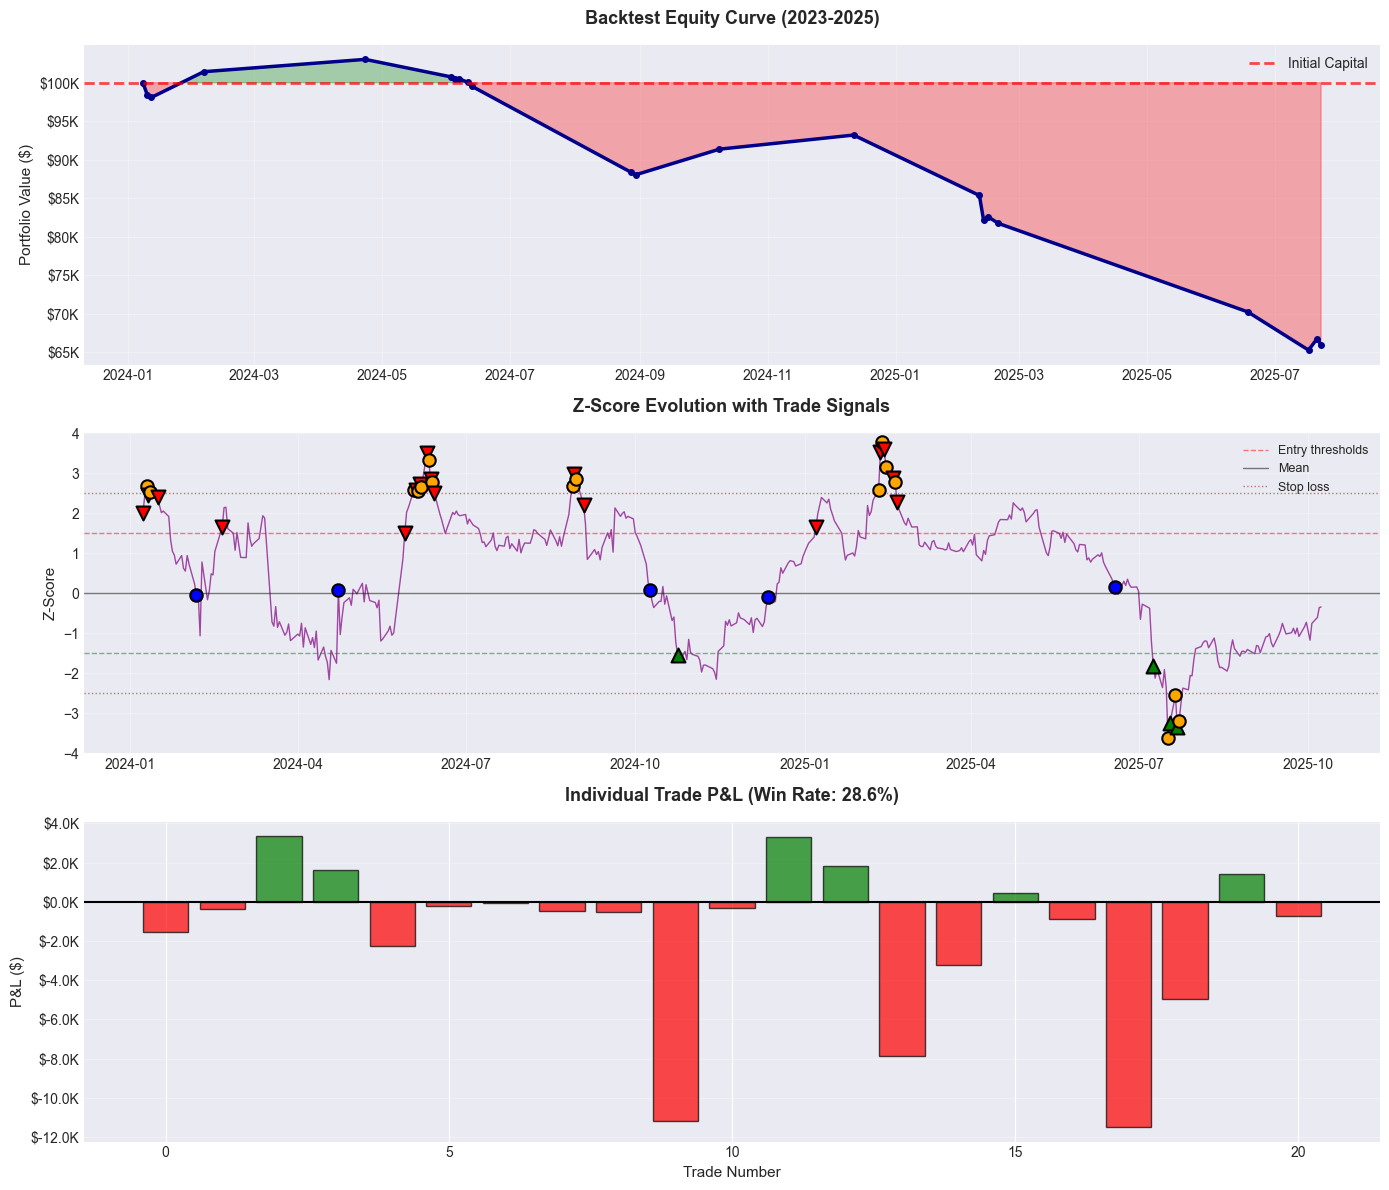


Backtest visualization complete!


In [47]:
# Visualize backtest results
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 1. Equity Curve
ax1 = axes[0]
dates_equity = [backtest_data.index[lookback_window]] + [t['exit_date'] for t in trades]
ax1.plot(dates_equity, equity_curve, linewidth=2.5, color='darkblue', marker='o', markersize=4)
ax1.axhline(y=initial_capital_backtest, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Initial Capital')
ax1.fill_between(dates_equity, initial_capital_backtest, equity_curve, 
                 where=np.array(equity_curve) >= initial_capital_backtest,
                 alpha=0.3, color='green', interpolate=True)
ax1.fill_between(dates_equity, equity_curve, initial_capital_backtest,
                 where=np.array(equity_curve) < initial_capital_backtest,
                 alpha=0.3, color='red', interpolate=True)
ax1.set_ylabel('Portfolio Value ($)', fontsize=11)
ax1.set_title('Backtest Equity Curve (2023-2025)', fontsize=13, fontweight='bold', pad=15)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# 2. Z-Score with Entry/Exit Points
ax2 = axes[1]
ax2.plot(backtest_data.index[lookback_window:], z_score_backtest.iloc[lookback_window:], 
        linewidth=1, color='purple', alpha=0.7)
ax2.axhline(y=entry_threshold, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Entry thresholds')
ax2.axhline(y=-entry_threshold, color='green', linestyle='--', linewidth=1, alpha=0.5)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5, label='Mean')
ax2.axhline(y=stop_loss_threshold, color='darkred', linestyle=':', linewidth=1, alpha=0.5, label='Stop loss')
ax2.axhline(y=-stop_loss_threshold, color='darkred', linestyle=':', linewidth=1, alpha=0.5)

# Mark entry points
for trade in trades:
    if trade['position_type'] == 'Long Spread':
        ax2.scatter(trade['entry_date'], trade['entry_z'], marker='^', s=100, 
                   color='green', edgecolors='black', linewidths=1.5, zorder=5)
    else:
        ax2.scatter(trade['entry_date'], trade['entry_z'], marker='v', s=100,
                   color='red', edgecolors='black', linewidths=1.5, zorder=5)
    
    # Mark exit points
    exit_color = 'blue' if trade['exit_reason'] == 'Mean Reversion' else 'orange'
    ax2.scatter(trade['exit_date'], trade['exit_z'], marker='o', s=80,
               color=exit_color, edgecolors='black', linewidths=1.5, zorder=5)

ax2.set_ylabel('Z-Score', fontsize=11)
ax2.set_title('Z-Score Evolution with Trade Signals', fontsize=13, fontweight='bold', pad=15)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([-4, 4])

# 3. Trade P&L Distribution
ax3 = axes[2]
if len(trades_df) > 0:
    colors_pnl = ['green' if x > 0 else 'red' for x in trades_df['pnl']]
    bars = ax3.bar(range(len(trades_df)), trades_df['pnl'], color=colors_pnl, alpha=0.7, edgecolor='black')
    ax3.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
    ax3.set_xlabel('Trade Number', fontsize=11)
    ax3.set_ylabel('P&L ($)', fontsize=11)
    ax3.set_title(f'Individual Trade P&L (Win Rate: {len(winning_trades)/len(trades_df)*100:.1f}%)', 
                 fontsize=13, fontweight='bold', pad=15)
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.1f}K'))

plt.tight_layout()
plt.show()

print("\nBacktest visualization complete!")